# Pinar del Rio

In [1]:
print(1)

1


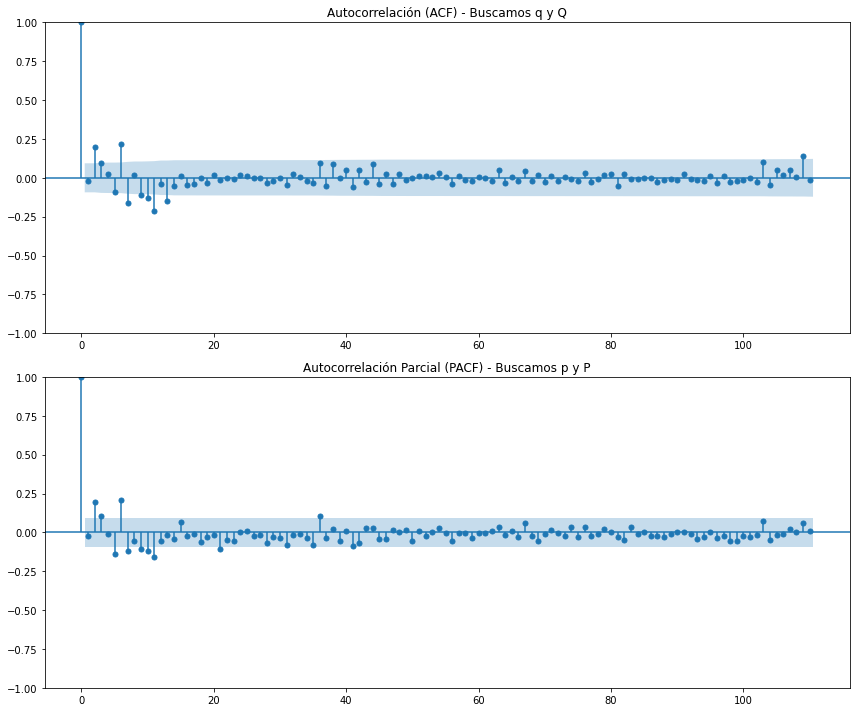

In [1]:
import pandas as pd
import os

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

nombre_provincia = 'Pinar del Río'

carpeta_salida = 'dataframes_con_lags'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df_pinar_del_rio = pd.read_csv(ruta_completa)

# lags=110 para ver claramente lo que pasa en el periodo 52 y 104
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
serie_diferenciada = df_pinar_del_rio["Casos_Dengue"].diff().dropna()
# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [2]:
df_pinar_del_rio= df_pinar_del_rio.drop(['Unnamed: 0', "Provincias"], axis=1)
df_pinar_del_rio.columns

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Temperatura med_lag17'],
      dtype='object')

In [3]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df_pinar_del_rio["Casos_Dengue"]
exog_vars =df_pinar_del_rio[["Temperatura med","Humedad Relat","Precipitaciones","Temperatura med_lag17"]]


n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")
variables_exog=df_pinar_del_rio[["Temperatura med","Humedad Relat","Precipitaciones","Temperatura med_lag17"]]

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 4155.446238547832
(0, 1, 0) (0, 0, 1, 52) 3638.8210693725255
(0, 1, 0) (0, 1, 0, 52) 3884.9755668596804
(0, 1, 0) (0, 1, 1, 52) 3259.7159907001205
(0, 1, 0) (1, 0, 0, 52) 3647.3915539478503


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 0) (1, 0, 1, 52) 3640.8054147384564
(0, 1, 0) (1, 1, 0, 52) 3320.7733694282183
(0, 1, 0) (1, 1, 1, 52) 3254.0388165088902
(0, 1, 1) (0, 0, 0, 52) 4147.828776863536
(0, 1, 1) (0, 0, 1, 52) 3631.70485863511
(0, 1, 1) (0, 1, 0, 52) 3876.963013442834
(0, 1, 1) (0, 1, 1, 52) 3252.3057493328142
(0, 1, 1) (1, 0, 0, 52) 3648.741405581077


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 1) (1, 0, 1, 52) 3633.6974684602847
(0, 1, 1) (1, 1, 0, 52) 3320.309597017682
(0, 1, 1) (1, 1, 1, 52) 3246.387123286495
(0, 1, 2) (0, 0, 0, 52) 4120.795141594502
(0, 1, 2) (0, 0, 1, 52) 3603.234717509278
(0, 1, 2) (0, 1, 0, 52) 3847.562904547267
(0, 1, 2) (0, 1, 1, 52) 3225.392111169623
(0, 1, 2) (1, 0, 0, 52) 3628.5342993277336
(0, 1, 2) (1, 0, 1, 52) 3605.1816755916534


...

(2, 1, 2) (1, 0, 1, 52) 3602.178977519648


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 0, 52) 3277.1730111836537


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 1, 52) 3217.965242815864
Mejor SARIMA: ((2, 1, 2), (1, 1, 1, 52)) con AIC: 3217.965242815864


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


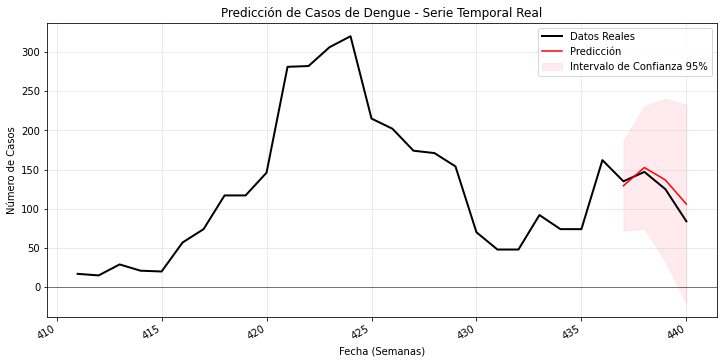

Error Absoluto Medio (MAE): 11.22 casos
Raíz del Error Cuadrático Medio (RMSE): 13.07 casos
Error Porcentual Absoluto Medio (MAPE): 10.88%


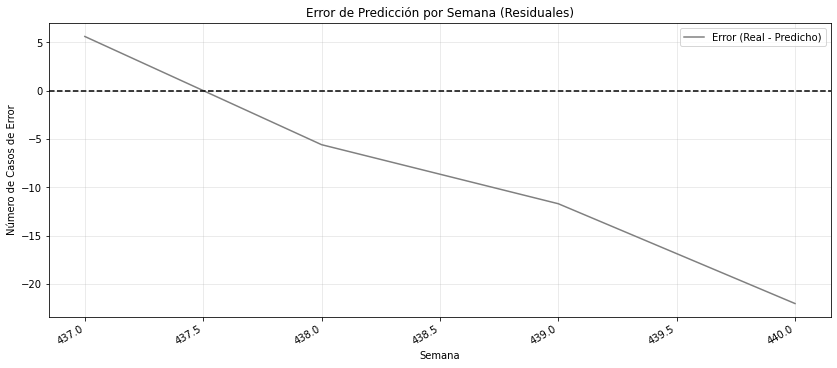

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# df_pinar_del_rio['Fecha'] = pd.to_datetime(df_pinar_del_rio['Fecha'])
# df_pinar_del_rio = df_pinar_del_rio.set_index('Fecha')


model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(2, 1, 2), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

In [4]:
df_pinar_del_rio

,Año_x,Semana Estadística,Fecha,Casos_Dengue,Temperatura med,Humedad Relat,Precipitaciones,Año_y,Mes,Temperatura med_lag17
0,2014,18,2014-05-05,0.0,26.150,77.500,36.1625,2014.0,5.0,21.7000
1,2014,19,2014-05-12,0.0,26.275,78.750,36.1625,2014.0,5.0,22.2125
2,2014,20,2014-05-19,33.0,26.400,80.000,36.1625,2014.0,5.0,22.7250
3,2014,21,2014-05-26,0.0,26.525,81.250,36.1625,2014.0,5.0,23.2375
4,2014,22,2014-06-02,0.0,26.650,82.500,37.3900,2014.0,6.0,23.7500
...,...,...,...,...,...,...,...,...,...,...
436,2022,45,2022-11-07,162.0,26.150,80.000,23.5375,2022.0,11.0,27.7375
437,2022,46,2022-11-14,135.0,25.600,79.625,23.5375,2022.0,11.0,27.7750
438,2022,47,2022-11-21,147.0,25.050,79.250,23.5375,2022.0,11.0,27.8125
439,2022,48,2022-11-28,125.0,24.500,78.875,23.5375,2022.0,11.0,27.8500


# Artemisa

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Precipitaciones_lag5'],
      dtype='object')


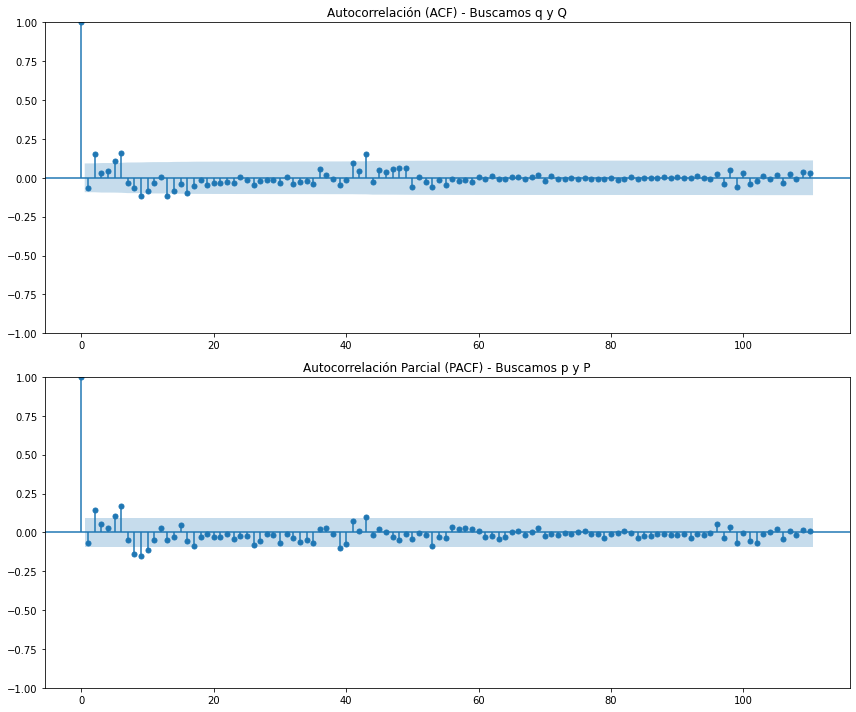

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Artemisa'

carpeta_salida = 'dataframes_con_lags'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df_artemisa = pd.read_csv(ruta_completa)

df_artemisa= df_artemisa.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df_artemisa.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df_artemisa["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [11]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df_artemisa["Casos_Dengue"]
exog_vars =df_artemisa[["Temperatura med","Humedad Relat","Precipitaciones","Precipitaciones_lag5"]]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 3373.9810230530647
(0, 1, 0) (0, 0, 1, 52) 3028.598765004487
(0, 1, 0) (0, 1, 0, 52) 3219.9989267032124
(0, 1, 0) (0, 1, 1, 52) 2640.539829945382
(0, 1, 0) (1, 0, 0, 52) 3035.6540831277644
(0, 1, 0) (1, 0, 1, 52) 3026.302335574937
(0, 1, 0) (1, 1, 0, 52) 2691.958139970294
(0, 1, 0) (1, 1, 1, 52) 2671.2676117737574
(0, 1, 1) (0, 0, 0, 52) 3365.549131018977
(0, 1, 1) (0, 0, 1, 52) 3019.7969412938637
(0, 1, 1) (0, 1, 0, 52) 3211.7532561849184
(0, 1, 1) (0, 1, 1, 52) 2635.9846031566485
(0, 1, 1) (1, 0, 0, 52) 3033.4999531395524
(0, 1, 1) (1, 0, 1, 52) 3018.8647132060046
(0, 1, 1) (1, 1, 0, 52) 2693.6670509051255
(0, 1, 1) (1, 1, 1, 52) 2664.4081453889567
(0, 1, 2) (0, 0, 0, 52) 3353.6064452521982
(0, 1, 2) (0, 0, 1, 52) 3009.582031123461
(0, 1, 2) (0, 1, 0, 52) 3192.8387810294803
(0, 1, 2) (0, 1, 1, 52) 2621.6170813900276
(0, 1, 2) (1, 0, 0, 52) 3029.805572126557
(0, 1, 2) (1, 0, 1, 52) 3007.50245350182
(0, 1, 2) (1, 1, 0, 52) 2679.981821286789
(0, 1, 2) (1, 1, 1, 5

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (0, 0, 0, 52) 3357.6176244169815


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (0, 0, 1, 52) 3013.606187128086
(2, 1, 2) (0, 1, 0, 52) 3192.5690910686035
(2, 1, 2) (0, 1, 1, 52) 2620.30874598275


...

(2, 1, 2) (1, 0, 0, 52) 3020.570462101423


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 0, 1, 52) 3011.3145973694554


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 0, 52) 2660.6190008839512
(2, 1, 2) (1, 1, 1, 52) 2653.266002842951
Mejor SARIMA: ((2, 1, 2), (0, 1, 1, 52)) con AIC: 2620.30874598275


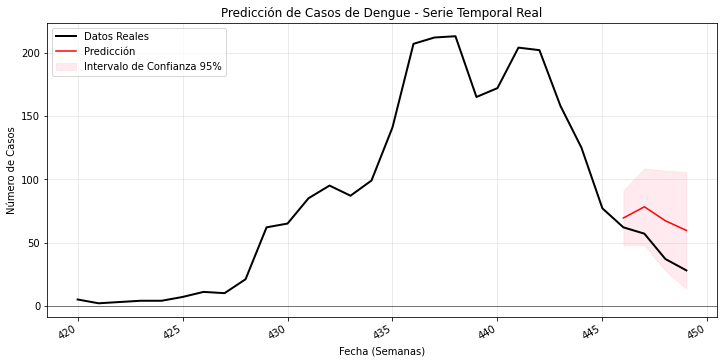

Error Absoluto Medio (MAE): 22.61 casos
Raíz del Error Cuadrático Medio (RMSE): 24.58 casos
Error Porcentual Absoluto Medio (MAPE): 60.92%


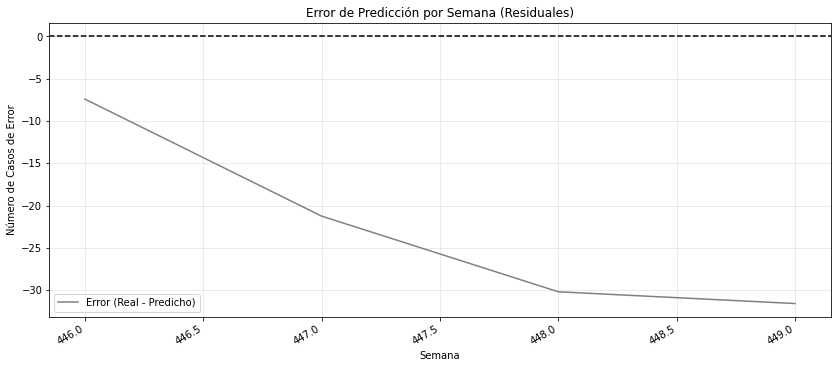

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# df_pinar_del_rio['Fecha'] = pd.to_datetime(df_pinar_del_rio['Fecha'])
# df_pinar_del_rio = df_pinar_del_rio.set_index('Fecha')


model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(2, 1, 2), 
                      seasonal_order=(0, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# La Habana

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Temperatura med_lag6'],
      dtype='object')


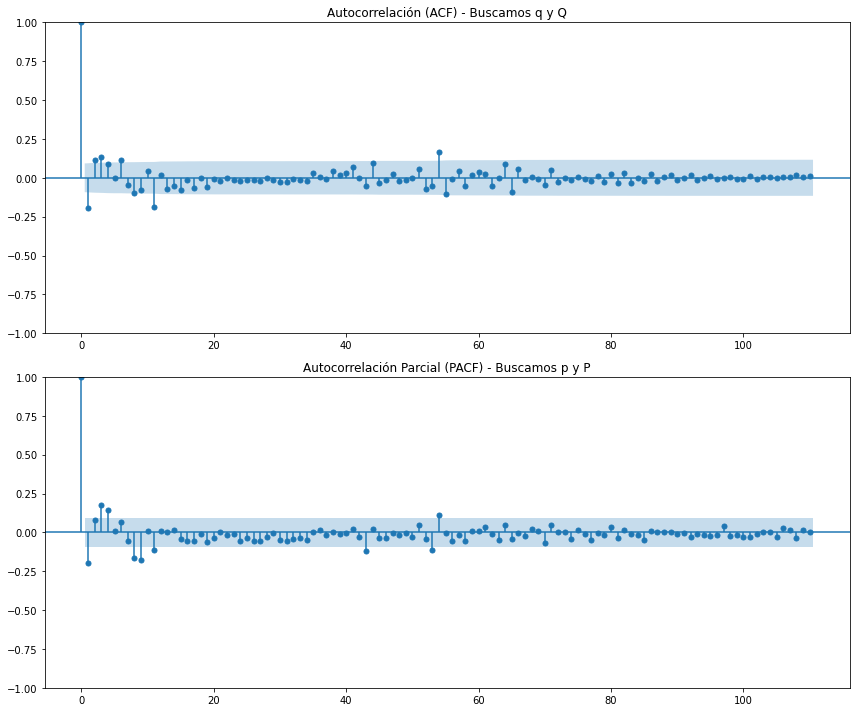

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'La_Habana'

carpeta_salida = 'dataframes_con_lags'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [ ]:
import itertools
import statsmodels.api as sm

p =  [0,1,2,3,4]
q=[0,1,2,3]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[["Temperatura med","Humedad Relat","Precipitaciones","Temperatura med_lag6"]]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 6059.384032158717
(0, 1, 0) (0, 0, 1, 52) 5313.4803489812075
(0, 1, 0) (0, 1, 0, 52) 5586.970488949629
(0, 1, 0) (0, 1, 1, 52) 4573.950635121595
(0, 1, 0) (1, 0, 0, 52) 5322.135092871225
(0, 1, 0) (1, 0, 1, 52) 5287.345386949814
(0, 1, 0) (1, 1, 0, 52) 4604.696270149427


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 0) (1, 1, 1, 52) 4593.799791801736
(0, 1, 1) (0, 0, 0, 52) 6030.964818405195


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 1) (0, 0, 1, 52) 5294.503172516637
(0, 1, 1) (0, 1, 0, 52) 5551.980114438491


...

(2, 1, 2) (1, 0, 1, 52) 5231.461458391389


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 0, 52) 4550.361956331048


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 1, 52) 4587.421064845182
Mejor SARIMA: ((1, 1, 2), (0, 1, 1, 52)) con AIC: 4523.362406760461


In [ ]:
import itertools
import statsmodels.api as sm
import re
import ast

output_anterior = """
(0, 1, 0) (0, 0, 0, 52) 6059.384032158717
(0, 1, 0) (0, 0, 1, 52) 5313.4803489812075
(0, 1, 0) (0, 1, 0, 52) 5586.970488949629
(0, 1, 0) (0, 1, 1, 52) 4573.950635121595
(0, 1, 0) (1, 0, 0, 52) 5322.135092871225
(0, 1, 0) (1, 0, 1, 52) 5287.345386949814
(0, 1, 0) (1, 1, 0, 52) 4604.696270149427
(0, 1, 0) (1, 1, 1, 52) 4593.799791801736
(0, 1, 1) (0, 0, 0, 52) 6030.964818405195
(0, 1, 1) (0, 0, 1, 52) 5294.503172516637
(0, 1, 1) (0, 1, 0, 52) 5551.980114438491
(0, 1, 1) (0, 1, 1, 52) 4563.683511690792
(0, 1, 1) (1, 0, 0, 52) 5315.300718636941
(0, 1, 1) (1, 0, 1, 52) 5271.970553827772
(0, 1, 1) (1, 1, 0, 52) 4606.990776810041
(0, 1, 1) (1, 1, 1, 52) 4564.715175158872
(0, 1, 2) (0, 0, 0, 52) 6010.198087590794
(0, 1, 2) (0, 0, 1, 52) 5272.672767362362
(0, 1, 2) (0, 1, 0, 52) 5537.891273201346
(0, 1, 2) (0, 1, 1, 52) 4527.0116921555
(0, 1, 2) (1, 0, 0, 52) 5302.089506510009
(0, 1, 2) (1, 0, 1, 52) 5238.453873287861
(0, 1, 2) (1, 1, 0, 52) 4585.871425084798
(0, 1, 2) (1, 1, 1, 52) 4528.204998073571
(1, 1, 0) (0, 0, 0, 52) 6040.214813263687
(1, 1, 0) (0, 0, 1, 52) 5304.608013826435
(1, 1, 0) (0, 1, 0, 52) 5564.952170202552
(1, 1, 0) (0, 1, 1, 52) 4576.127074674604
(1, 1, 0) (1, 0, 0, 52) 5299.333288004148
(1, 1, 0) (1, 0, 1, 52) 5281.903528973169
(1, 1, 0) (1, 1, 0, 52) 4594.5486723520125
(1, 1, 0) (1, 1, 1, 52) 4577.207126381401
(1, 1, 1) (0, 0, 0, 52) 6029.168841022868
(1, 1, 1) (0, 0, 1, 52) 5288.38125157512
(1, 1, 1) (0, 1, 0, 52) 5552.871712358843
(1, 1, 1) (0, 1, 1, 52) 4560.6939900873085
(1, 1, 1) (1, 0, 0, 52) 5294.61260825988
(1, 1, 1) (1, 0, 1, 52) 5262.917527278227
(1, 1, 1) (1, 1, 0, 52) 4590.786030399402
(1, 1, 1) (1, 1, 1, 52) 4559.252955968791
(1, 1, 2) (0, 0, 0, 52) 5995.046224553936
(1, 1, 2) (0, 0, 1, 52) 5261.901665339383
(1, 1, 2) (0, 1, 0, 52) 5518.754000031083
(1, 1, 2) (0, 1, 1, 52) 4523.362406760461
(1, 1, 2) (1, 0, 0, 52) 5280.363235892015
(1, 1, 2) (1, 0, 1, 52) 5232.546674310064
(1, 1, 2) (1, 1, 0, 52) 4566.261994284305
(1, 1, 2) (1, 1, 1, 52) 4543.043297728638
(2, 1, 0) (0, 0, 0, 52) 6028.654842828209
(2, 1, 0) (0, 0, 1, 52) 5299.80880734608
(2, 1, 0) (0, 1, 0, 52) 5552.0489899783115
(2, 1, 0) (0, 1, 1, 52) 4551.771421736927
(2, 1, 0) (1, 0, 0, 52) 5278.732370631575
(2, 1, 0) (1, 0, 1, 52) 5252.232097366987
(2, 1, 0) (1, 1, 0, 52) 4559.764143057953
(2, 1, 0) (1, 1, 1, 52) 4561.2655633635895
(2, 1, 1) (0, 0, 0, 52) 6026.3885920050625
(2, 1, 1) (0, 0, 1, 52) 5281.47344412697
(2, 1, 1) (0, 1, 0, 52) 5554.06143973478
(2, 1, 1) (0, 1, 1, 52) 4535.5208556587895
(2, 1, 1) (1, 0, 0, 52) 5287.479400678905
(2, 1, 1) (1, 0, 1, 52) 5246.746771947135
(2, 1, 1) (1, 1, 0, 52) 4554.644186895788
(2, 1, 1) (1, 1, 1, 52) 4536.728304242253
(2, 1, 2) (0, 0, 0, 52) 5984.996292061111
(2, 1, 2) (0, 0, 1, 52) 5255.262842560683
(2, 1, 2) (0, 1, 0, 52) 5505.61682351301
(2, 1, 2) (0, 1, 1, 52) 4567.378030810215
(2, 1, 2) (1, 0, 0, 52) 5264.312709140594
(2, 1, 2) (1, 0, 1, 52) 5231.461458391389
(2, 1, 2) (1, 1, 0, 52) 4550.361956331048
(2, 1, 2) (1, 1, 1, 52) 4587.421064845182
"""

pattern = re.compile(r'\((.*?)\)\s\((.*?)\)\s([\d.]+)')

resultados_anteriores = {}
for line in output_anterior.strip().split('\n'):
    match = pattern.search(line)
    if match:

        order_str = match.group(1)
        seasonal_order_str = match.group(2)
        aic_str = match.group(3)
        
        order = ast.literal_eval(f"({order_str})")
        seasonal_order = ast.literal_eval(f"({seasonal_order_str})") 
        
        aic = float(aic_str)
        
        # Guardar en el diccionario
        resultados_anteriores[(order, seasonal_order)] = aic

print(f"Se cargaron {len(resultados_anteriores)} resultados anteriores.")

p =  [0,1,2,3,4]
q=[0,1,2,3]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]

y = df["Casos_Dengue"]
exog_vars =df[["Temperatura med","Humedad Relat","Precipitaciones","Temperatura med_lag6"]]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

if resultados_anteriores:
    mejores_params_anteriores = min(resultados_anteriores, key=resultados_anteriores.get)
    mejor_aic = resultados_anteriores[mejores_params_anteriores]
    mejores_params = mejores_params_anteriores
    print(f"Reanudando búsqueda. Mejor resultado anterior: {mejores_params} con AIC: {mejor_aic}")
else:
    mejores_params = None
    mejor_aic = float("inf")
    print("Iniciando nueva búsqueda.")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        
        if (param, param_seasonal) in resultados_anteriores:
            continue
            
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(f"  {param} {param_seasonal} - AIC: {results.aic}")

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                print(f"*** ¡NUEVO MEJOR! {mejores_params} con AIC: {mejor_aic} ***")
                
        except Exception as e:
            continue

print("\n--- BÚSQUEDA FINALIZADA ---")
print(f"Mejor SARIMA encontrado: {mejores_params} con AIC: {mejor_aic}")

Se cargaron 72 resultados anteriores.
Reanudando búsqueda. Mejor resultado anterior: ((1, 1, 2), (0, 1, 1, 52)) con AIC: 4523.362406760461
Calculando nuevo: (0, 1, 3) (0, 0, 0, 52) - AIC: 5989.986479366283


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Calculando nuevo: (0, 1, 3) (0, 0, 1, 52) - AIC: 5257.699771902602
Calculando nuevo: (0, 1, 3) (0, 1, 0, 52) - AIC: 5509.960946397789
Calculando nuevo: (0, 1, 3) (0, 1, 1, 52) - AIC: 4516.1800145285215
*** ¡NUEVO MEJOR! ((0, 1, 3), (0, 1, 1, 52)) con AIC: 4516.1800145285215 ***


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Calculando nuevo: (0, 1, 3) (1, 0, 0, 52) - AIC: 5301.361948315712
Calculando nuevo: (0, 1, 3) (1, 0, 1, 52) - AIC: 5227.484403789319
Calculando nuevo: (0, 1, 3) (1, 1, 0, 52) - AIC: 4586.679114156944
Calculando nuevo: (0, 1, 3) (1, 1, 1, 52) - AIC: 4517.35284367817
Calculando nuevo: (1, 1, 3) (0, 0, 0, 52) - AIC: 5978.110092248578


...

Calculando nuevo: (4, 1, 3) (1, 0, 1, 52) - AIC: 5220.527392924652


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Calculando nuevo: (4, 1, 3) (1, 1, 0, 52) - AIC: 4595.843117468441


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Calculando nuevo: (4, 1, 3) (1, 1, 1, 52) - AIC: 4590.312845831231

--- BÚSQUEDA FINALIZADA ---
Mejor SARIMA encontrado: ((4, 1, 1), (1, 1, 1, 52)) con AIC: 4504.600427095378


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


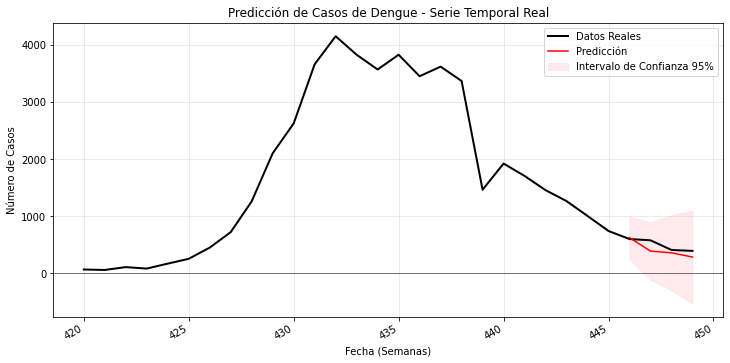

Error Absoluto Medio (MAE): 92.55 casos
Raíz del Error Cuadrático Medio (RMSE): 112.14 casos
Error Porcentual Absoluto Medio (MAPE): 18.98%


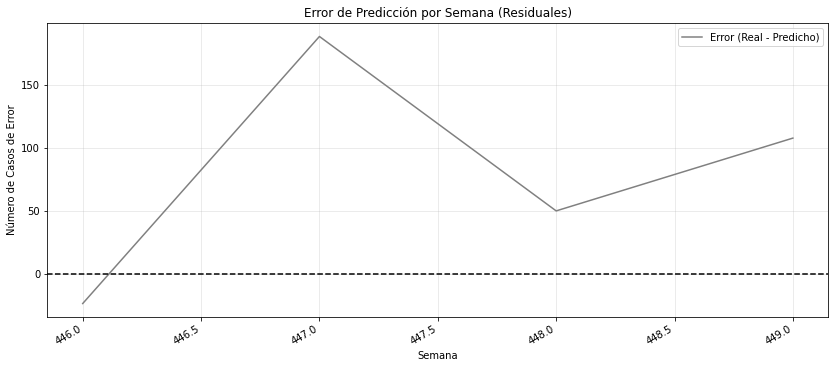

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(4, 1, 1), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Mayabeque

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Precipitaciones_lag5', 'Precipitaciones_lag13'],
      dtype='object')


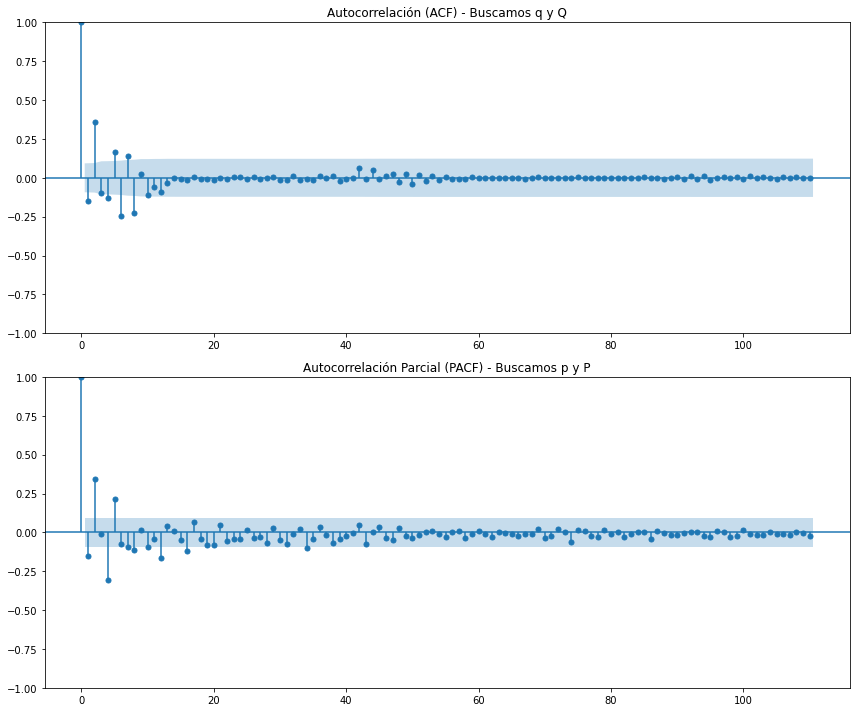

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Mayabeque'

carpeta_salida = 'dataframes_con_lags'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [24]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[["Temperatura med","Humedad Relat","Precipitaciones",'Precipitaciones_lag5', 'Precipitaciones_lag13']]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 3839.901341211069
(0, 1, 0) (0, 0, 1, 52) 3435.4082966045726
(0, 1, 0) (0, 1, 0, 52) 3485.018862582725
(0, 1, 0) (0, 1, 1, 52) 3032.481248243355
(0, 1, 0) (1, 0, 0, 52) 3442.8702322408003
(0, 1, 0) (1, 0, 1, 52) 3437.030789842293
(0, 1, 0) (1, 1, 0, 52) 3045.8939357156387
(0, 1, 0) (1, 1, 1, 52) 3038.5035957063556
(0, 1, 1) (0, 0, 0, 52) 3827.333509496762
(0, 1, 1) (0, 0, 1, 52) 3423.6407255446015
(0, 1, 1) (0, 1, 0, 52) 3476.2174520685785
(0, 1, 1) (0, 1, 1, 52) 3022.286726422357
(0, 1, 1) (1, 0, 0, 52) 3439.048173855483
(0, 1, 1) (1, 0, 1, 52) 3425.387465817086
(0, 1, 1) (1, 1, 0, 52) 3044.077085499322
(0, 1, 1) (1, 1, 1, 52) 3028.3127582658926
(0, 1, 2) (0, 0, 0, 52) 3742.5275167539626
(0, 1, 2) (0, 0, 1, 52) 3348.2663034383286
(0, 1, 2) (0, 1, 0, 52) 3414.7108058355234
(0, 1, 2) (0, 1, 1, 52) 2961.334690352968
(0, 1, 2) (1, 0, 0, 52) 3371.079561535119
(0, 1, 2) (1, 0, 1, 52) 3349.854930312362
(0, 1, 2) (1, 1, 0, 52) 2993.8250447001938
(0, 1, 2) (1, 1, 1, 52)

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (0, 0, 1, 52) 3335.2211613125583
(2, 1, 2) (0, 1, 0, 52) 3403.746298846862


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (0, 1, 1, 52) 2947.2737999450655


...

(2, 1, 2) (1, 0, 1, 52) 3336.881182995289


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 0, 52) 2962.1676426125346


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 1, 52) 2953.391962732681
Mejor SARIMA: ((2, 1, 2), (0, 1, 1, 52)) con AIC: 2947.2737999450655


In [15]:
import itertools
import statsmodels.api as sm
import re
import ast

output_anterior = """
(0, 1, 0) (0, 0, 0, 52) 3839.901341211069
(0, 1, 0) (0, 0, 1, 52) 3435.4082966045726
(0, 1, 0) (0, 1, 0, 52) 3485.018862582725
(0, 1, 0) (0, 1, 1, 52) 3032.481248243355
(0, 1, 0) (1, 0, 0, 52) 3442.8702322408003
(0, 1, 0) (1, 0, 1, 52) 3437.030789842293
(0, 1, 0) (1, 1, 0, 52) 3045.8939357156387
(0, 1, 0) (1, 1, 1, 52) 3038.5035957063556
(0, 1, 1) (0, 0, 0, 52) 3827.333509496762
(0, 1, 1) (0, 0, 1, 52) 3423.6407255446015
(0, 1, 1) (0, 1, 0, 52) 3476.2174520685785
(0, 1, 1) (0, 1, 1, 52) 3022.286726422357
(0, 1, 1) (1, 0, 0, 52) 3439.048173855483
(0, 1, 1) (1, 0, 1, 52) 3425.387465817086
(0, 1, 1) (1, 1, 0, 52) 3044.077085499322
(0, 1, 1) (1, 1, 1, 52) 3028.3127582658926
(0, 1, 2) (0, 0, 0, 52) 3742.5275167539626
(0, 1, 2) (0, 0, 1, 52) 3348.2663034383286
(0, 1, 2) (0, 1, 0, 52) 3414.7108058355234
(0, 1, 2) (0, 1, 1, 52) 2961.334690352968
(0, 1, 2) (1, 0, 0, 52) 3371.079561535119
(0, 1, 2) (1, 0, 1, 52) 3349.854930312362
(0, 1, 2) (1, 1, 0, 52) 2993.8250447001938
(0, 1, 2) (1, 1, 1, 52) 2970.0408226561945
(1, 1, 0) (0, 0, 0, 52) 3831.001540053657
(2, 1, 1) (1, 0, 1, 52) 3386.315904161872
(2, 1, 1) (1, 1, 0, 52) 2998.0651462343203
(2, 1, 1) (1, 1, 1, 52) 2998.860266635665
(2, 1, 2) (0, 0, 0, 52) 3726.9902808129154
(2, 1, 2) (0, 0, 1, 52) 3335.2211613125583
(2, 1, 2) (0, 1, 0, 52) 3403.746298846862
(2, 1, 2) (0, 1, 1, 52) 2947.2737999450655
(2, 1, 2) (1, 0, 0, 52) 3342.5912833682173
(2, 1, 2) (1, 0, 1, 52) 3336.881182995289
(2, 1, 2) (1, 1, 0, 52) 2962.1676426125346
(2, 1, 2) (1, 1, 1, 52) 2953.391962732681
"""

pattern = re.compile(r'\((.*?)\)\s\((.*?)\)\s([\d.]+)')

resultados_anteriores = {}
for line in output_anterior.strip().split('\n'):
    match = pattern.search(line)
    if match:

        order_str = match.group(1)
        seasonal_order_str = match.group(2)
        aic_str = match.group(3)
        
        order = ast.literal_eval(f"({order_str})")
        seasonal_order = ast.literal_eval(f"({seasonal_order_str})") 
        
        aic = float(aic_str)
        
        # Guardar en el diccionario
        resultados_anteriores[(order, seasonal_order)] = aic

print(f"Se cargaron {len(resultados_anteriores)} resultados anteriores.")

p =  [0,1,2]
q=[0,1,2,4,5,6,7,8]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]

y = df["Casos_Dengue"]
exog_vars =df[["Temperatura med","Humedad Relat","Precipitaciones",'Precipitaciones_lag5', 'Precipitaciones_lag13']]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

if resultados_anteriores:
    mejores_params_anteriores = min(resultados_anteriores, key=resultados_anteriores.get)
    mejor_aic = resultados_anteriores[mejores_params_anteriores]
    mejores_params = mejores_params_anteriores
    print(f"Reanudando búsqueda. Mejor resultado anterior: {mejores_params} con AIC: {mejor_aic}")
else:
    mejores_params = None
    mejor_aic = float("inf")
    print("Iniciando nueva búsqueda.")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        
        if (param, param_seasonal) in resultados_anteriores:
            continue
            
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(f"{param} {param_seasonal} - AIC: {results.aic}")

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                print(f"*** ¡NUEVO MEJOR! {mejores_params} con AIC: {mejor_aic} ***")
                
        except Exception as e:
            continue

print("\n--- BÚSQUEDA FINALIZADA ---")
print(f"Mejor SARIMA encontrado: {mejores_params} con AIC: {mejor_aic}")

Se cargaron 36 resultados anteriores.
Reanudando búsqueda. Mejor resultado anterior: ((2, 1, 2), (0, 1, 1, 52)) con AIC: 2947.2737999450655
(0, 1, 4) (0, 0, 0, 52) - AIC: 3707.2695835616096
(0, 1, 4) (0, 0, 1, 52) - AIC: 3315.841666938909
(0, 1, 4) (0, 1, 0, 52) - AIC: 3386.222954511458
(0, 1, 4) (0, 1, 1, 52) - AIC: 2928.633911275346
*** ¡NUEVO MEJOR! ((0, 1, 4), (0, 1, 1, 52)) con AIC: 2928.633911275346 ***
(0, 1, 4) (1, 0, 0, 52) - AIC: 3353.863373657326


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 4) (1, 0, 1, 52) - AIC: 3317.580307815716
(0, 1, 4) (1, 1, 0, 52) - AIC: 2976.955521993277
(0, 1, 4) (1, 1, 1, 52) - AIC: 2935.9751060763006
(0, 1, 5) (0, 0, 0, 52) - AIC: 3701.374488849877
(0, 1, 5) (0, 0, 1, 52) - AIC: 3309.9635074032876
(0, 1, 5) (0, 1, 0, 52) - AIC: 3380.147090279305
(0, 1, 5) (0, 1, 1, 52) - AIC: 2920.7831627398295
*** ¡NUEVO MEJOR! ((0, 1, 5), (0, 1, 1, 52)) con AIC: 2920.7831627398295 ***
(0, 1, 5) (1, 0, 0, 52) - AIC: 3355.612703036327


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 5) (1, 0, 1, 52) - AIC: 3311.7142310754352
(0, 1, 5) (1, 1, 0, 52) - AIC: 2974.4785998466004


...

(2, 1, 8) (0, 1, 1, 52) - AIC: 2856.41386618571
(2, 1, 8) (1, 0, 0, 52) - AIC: 3290.5769753219192
(2, 1, 8) (1, 0, 1, 52) - AIC: 3240.1620922430493


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 8) (1, 1, 0, 52) - AIC: 2917.980798449316


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 8) (1, 1, 1, 52) - AIC: 2864.1188852077266

--- BÚSQUEDA FINALIZADA ---
Mejor SARIMA encontrado: ((0, 1, 8), (0, 1, 1, 52)) con AIC: 2852.755934583075


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


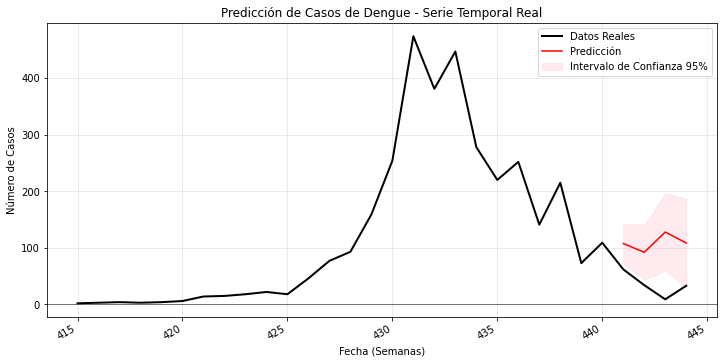

Error Absoluto Medio (MAE): 74.54 casos
Raíz del Error Cuadrático Medio (RMSE): 79.55 casos
Error Porcentual Absoluto Medio (MAPE): 448.82%


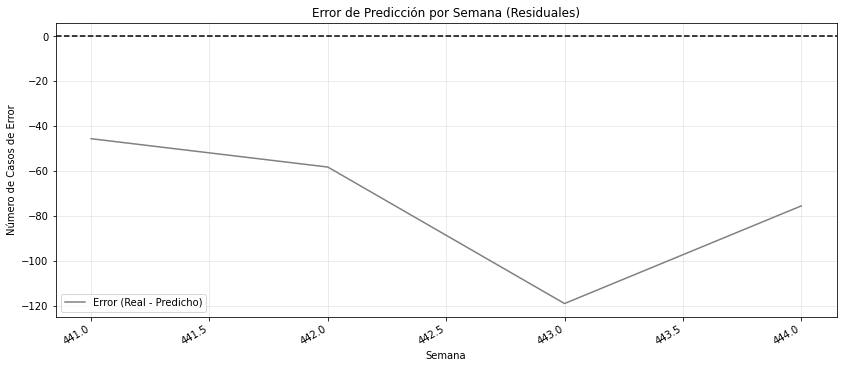

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(0, 1, 8), 
                      seasonal_order=(0, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


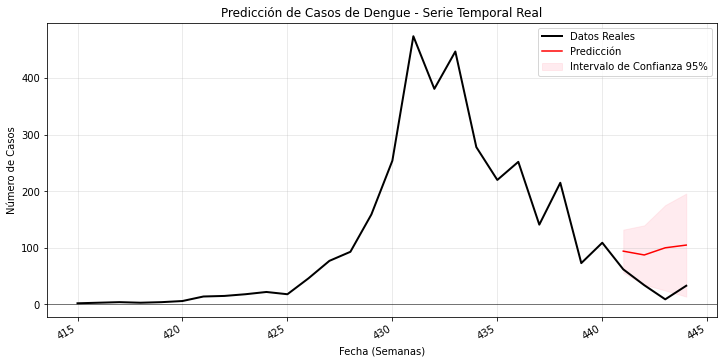

Error Absoluto Medio (MAE): 62.12 casos
Raíz del Error Cuadrático Medio (RMSE): 65.85 casos
Error Porcentual Absoluto Medio (MAPE): 359.67%


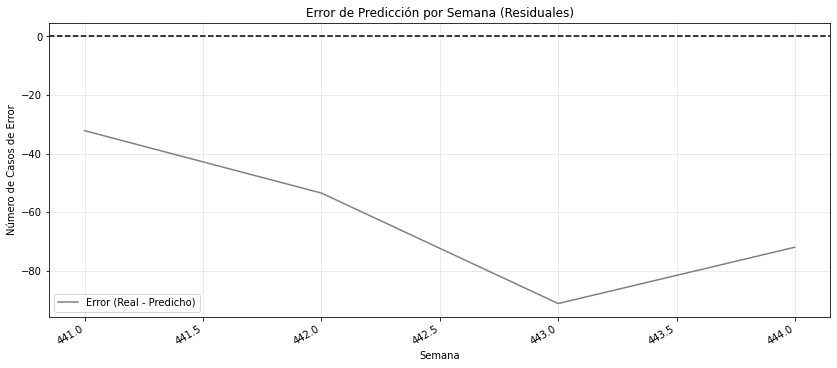

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(2, 1, 2), 
                      seasonal_order=(0, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Matanzas

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


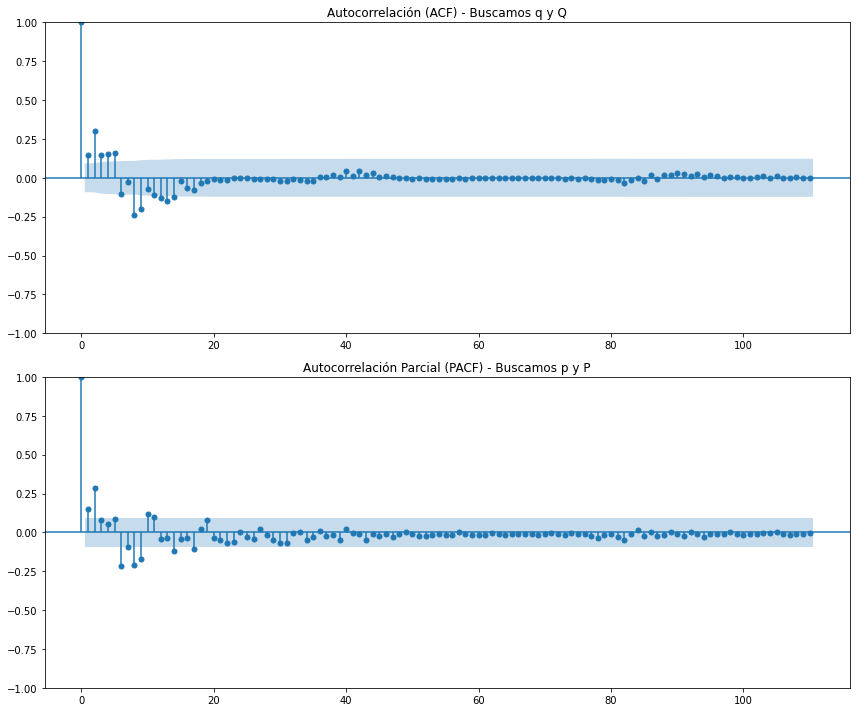

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Matanzas'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [22]:
import itertools
import statsmodels.api as sm

q =  [0,1,2,3,4,5]
p=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[['Temp_Med','Hum_Rel', 'Precip']]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 4182.937342676787
(0, 1, 0) (0, 0, 1, 52) 3750.0639359041725
(0, 1, 0) (0, 1, 0, 52) 3781.8423819078207
(0, 1, 0) (0, 1, 1, 52) 3302.4239636890334
(0, 1, 0) (1, 0, 0, 52) 3758.374090288893
(0, 1, 0) (1, 0, 1, 52) 3751.9362551692216
(0, 1, 0) (1, 1, 0, 52) 3308.054087123606
(0, 1, 0) (1, 1, 1, 52) 3301.218735675435
(0, 1, 1) (0, 0, 0, 52) 4171.215809864721
(0, 1, 1) (0, 0, 1, 52) 3738.8403456549117
(0, 1, 1) (0, 1, 0, 52) 3772.10201838678
(0, 1, 1) (0, 1, 1, 52) 3291.1732672549715
(0, 1, 1) (1, 0, 0, 52) 3755.582787230559
(0, 1, 1) (1, 0, 1, 52) 3740.7289516217506
(0, 1, 1) (1, 1, 0, 52) 3306.251638134442
(0, 1, 1) (1, 1, 1, 52) 3290.916619165171
(0, 1, 2) (0, 0, 0, 52) 4132.709779890016
(0, 1, 2) (0, 0, 1, 52) 3704.0370411123786
(0, 1, 2) (0, 1, 0, 52) 3736.86481802914
(0, 1, 2) (0, 1, 1, 52) 3259.5958332421715
(0, 1, 2) (1, 0, 0, 52) 3729.082242226592


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 2) (1, 0, 1, 52) 3706.0115047835275
(0, 1, 2) (1, 1, 0, 52) 3283.762636683952
(0, 1, 2) (1, 1, 1, 52) 3259.8844120880685
(0, 1, 3) (0, 0, 0, 52) 4125.081627633323
(0, 1, 3) (0, 0, 1, 52) 3696.2522564290166
(0, 1, 3) (0, 1, 0, 52) 3729.20020991213
(0, 1, 3) (0, 1, 1, 52) 3251.1731274433805
(0, 1, 3) (1, 0, 0, 52) 3729.840123323461


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 3) (1, 0, 1, 52) 3698.234116598199
(0, 1, 3) (1, 1, 0, 52) 3283.7933532992174


...

(2, 1, 5) (1, 0, 1, 52) 3615.0841462825556


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 5) (1, 1, 0, 52) 3205.485305435387


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 5) (1, 1, 1, 52) 3172.590634860703
Mejor SARIMA: ((1, 1, 5), (1, 1, 1, 52)) con AIC: 3172.124476888924


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


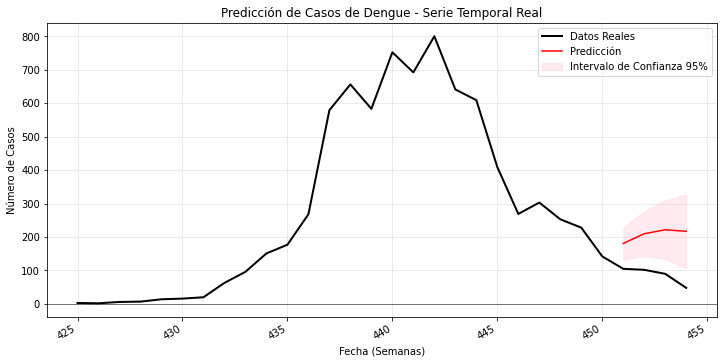

Error Absoluto Medio (MAE): 121.09 casos
Raíz del Error Cuadrático Medio (RMSE): 125.79 casos
Error Porcentual Absoluto Medio (MAPE): 169.13%


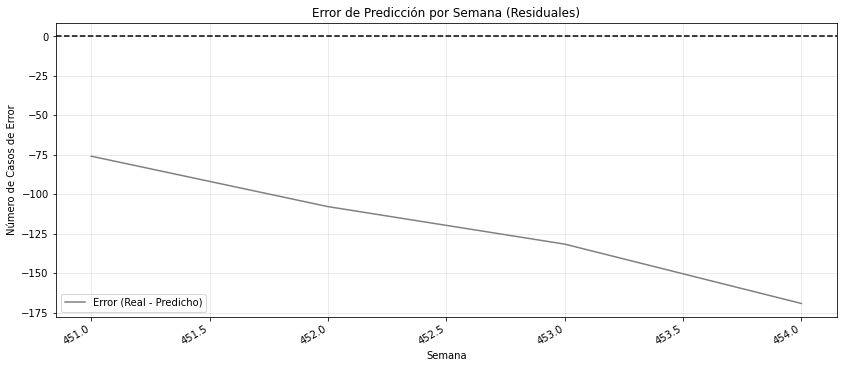

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(1, 1, 5), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Cienfuegos

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


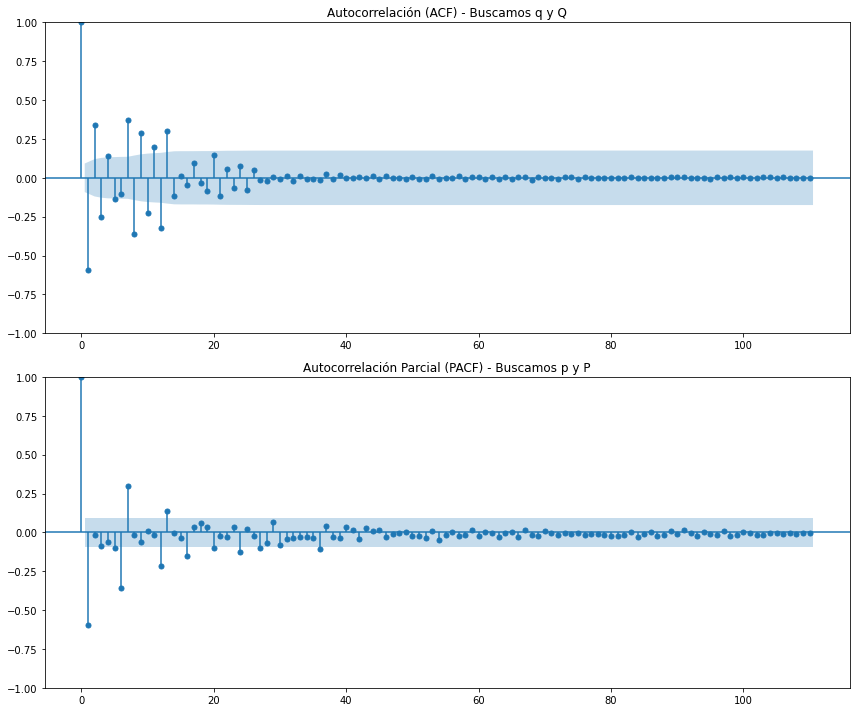

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Cienfuegos'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [ ]:
import itertools
import statsmodels.api as sm

p =  [0,1,2,6]
q=[0,1,2,6]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[["Temp_Med","Hum_Rel","Precip"]]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 5108.736955366446
(0, 1, 0) (0, 0, 1, 52) 3584.5262597126775
(0, 1, 0) (0, 1, 0, 52) 4598.40453469402
(0, 1, 0) (0, 1, 1, 52) 3361.017853707333
(0, 1, 0) (1, 0, 0, 52) 3592.640659343507
(0, 1, 0) (1, 0, 1, 52) 3586.339232641476
(0, 1, 0) (1, 1, 0, 52) 3371.833748211471
(0, 1, 0) (1, 1, 1, 52) 3309.027759693259
(0, 1, 1) (0, 0, 0, 52) 4911.3608797171655
(0, 1, 1) (0, 0, 1, 52) 3532.352129787429
(0, 1, 1) (0, 1, 0, 52) 4468.958083460217
(0, 1, 1) (0, 1, 1, 52) 3297.3847535981745
(0, 1, 1) (1, 0, 0, 52) 3548.5299968279314
(0, 1, 1) (1, 0, 1, 52) 3534.1930555143176
(0, 1, 1) (1, 1, 0, 52) 3316.887904394348


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 1) (1, 1, 1, 52) 3262.4598906402553
(0, 1, 2) (0, 0, 0, 52) 4893.691692166105
(0, 1, 2) (0, 0, 1, 52) 3517.776683088091
(0, 1, 2) (0, 1, 0, 52) 4445.751487291164
(0, 1, 2) (0, 1, 1, 52) 3277.8733491604817
(0, 1, 2) (1, 0, 0, 52) 3542.7110917117557
(0, 1, 2) (1, 0, 1, 52) 3519.6909817788664


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 2) (1, 1, 0, 52) 3306.59993433847


...

(6, 1, 6) (1, 0, 1, 52) 3470.622876186209


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(6, 1, 6) (1, 1, 0, 52) 3233.005923995188


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(6, 1, 6) (1, 1, 1, 52) 3151.108279946409
Mejor SARIMA: ((0, 1, 6), (1, 1, 1, 52)) con AIC: 3113.823742600576


In [27]:
import itertools
import statsmodels.api as sm
import re
import ast

output_anterior = """
(0, 1, 0) (0, 0, 0, 52) 5108.736955366446
(0, 1, 0) (0, 0, 1, 52) 3584.5262597126775
(0, 1, 0) (0, 1, 0, 52) 4598.40453469402
(0, 1, 0) (0, 1, 1, 52) 3361.017853707333
(0, 1, 0) (1, 0, 0, 52) 3592.640659343507
(0, 1, 0) (1, 0, 1, 52) 3586.339232641476
(0, 1, 0) (1, 1, 0, 52) 3371.833748211471
(0, 1, 0) (1, 1, 1, 52) 3309.027759693259
(0, 1, 1) (0, 0, 0, 52) 4911.3608797171655
(0, 1, 1) (0, 0, 1, 52) 3532.352129787429
(0, 1, 1) (0, 1, 0, 52) 4468.958083460217
(0, 1, 1) (0, 1, 1, 52) 3297.3847535981745
(0, 1, 1) (1, 0, 0, 52) 3548.5299968279314
(0, 1, 1) (1, 0, 1, 52) 3534.1930555143176
(0, 1, 1) (1, 1, 0, 52) 3316.887904394348
(0, 1, 1) (1, 1, 1, 52) 3262.4598906402553
(0, 1, 2) (0, 0, 0, 52) 4893.691692166105
(0, 1, 2) (0, 0, 1, 52) 3517.776683088091
(0, 1, 2) (0, 1, 0, 52) 4445.751487291164
(0, 1, 2) (0, 1, 1, 52) 3277.8733491604817
(0, 1, 2) (1, 0, 0, 52) 3542.7110917117557
(0, 1, 2) (1, 0, 1, 52) 3519.6909817788664
(0, 1, 2) (1, 1, 0, 52) 3306.59993433847
(0, 1, 2) (1, 1, 1, 52) 3158.7779813871325
(0, 1, 6) (0, 0, 0, 52) 4770.071051978597
(0, 1, 6) (0, 0, 1, 52) 3468.501493853106
(0, 1, 6) (0, 1, 0, 52) 4308.090637644395
(0, 1, 6) (0, 1, 1, 52) 3231.5526200342865
(0, 1, 6) (1, 0, 0, 52) 3524.9048859693694
(0, 1, 6) (1, 0, 1, 52) 3470.363893699423
(0, 1, 6) (1, 1, 0, 52) 3294.875673594444
(0, 1, 6) (1, 1, 1, 52) 3113.823742600576
(1, 1, 0) (0, 0, 0, 52) 4900.816626739806
(1, 1, 0) (0, 0, 1, 52) 3537.7491063146217
(1, 1, 0) (0, 1, 0, 52) 4461.744209409299
(1, 1, 0) (0, 1, 1, 52) 3302.4043637210134
(1, 1, 0) (1, 0, 0, 52) 3537.471298719538
(1, 1, 0) (1, 0, 1, 52) 3539.4031529537647
(1, 1, 0) (1, 1, 0, 52) 3302.365453754479
(1, 1, 0) (1, 1, 1, 52) 3172.819586163755
(1, 1, 1) (0, 0, 0, 52) 4883.561464533769
(1, 1, 1) (0, 0, 1, 52) 3533.076654648874
(1, 1, 1) (0, 1, 0, 52) 4439.111167445144
(1, 1, 1) (0, 1, 1, 52) 3345.1938500187503
(1, 1, 1) (1, 0, 0, 52) 3574.843803116849
(1, 1, 1) (1, 0, 1, 52) 3568.982528814119
(1, 1, 1) (1, 1, 0, 52) 3301.388411966226
(1, 1, 1) (1, 1, 1, 52) 3165.28791761477
(1, 1, 2) (0, 0, 0, 52) 4874.301366121736
(1, 1, 2) (0, 0, 1, 52) 3504.6648718372367
(1, 1, 2) (0, 1, 0, 52) 4430.711449006572
(1, 1, 2) (0, 1, 1, 52) 3279.134639639712
(1, 1, 2) (1, 0, 0, 52) 3521.497572233222
(1, 1, 2) (1, 0, 1, 52) 3506.4507063089713
(1, 1, 2) (1, 1, 0, 52) 3297.908953672627
(1, 1, 2) (1, 1, 1, 52) 3160.823869931323
(1, 1, 6) (0, 0, 0, 52) 4740.251842880418
(1, 1, 6) (0, 0, 1, 52) 3460.7843610804803
(1, 1, 6) (0, 1, 0, 52) 4309.854966249195
(1, 1, 6) (0, 1, 1, 52) 3241.495319379975
(1, 1, 6) (1, 0, 0, 52) 3511.565233646327
(1, 1, 6) (1, 0, 1, 52) 3465.883680264292
(1, 1, 6) (1, 1, 0, 52) 3326.4923100767746
(1, 1, 6) (1, 1, 1, 52) 3250.4678210786024
(2, 1, 0) (0, 0, 0, 52) 4883.56464105429
(2, 1, 0) (0, 0, 1, 52) 3537.5353434437
(2, 1, 0) (0, 1, 0, 52) 4439.838485131073
(2, 1, 0) (0, 1, 1, 52) 3298.560649057952
(2, 1, 0) (1, 0, 0, 52) 3529.0668025007894
(2, 1, 0) (1, 0, 1, 52) 3530.9964565366136
(2, 1, 0) (1, 1, 0, 52) 3289.5405879228174
(2, 1, 0) (1, 1, 1, 52) 3163.4079075126037
(2, 1, 1) (0, 0, 0, 52) 4868.256308776832
(2, 1, 1) (0, 0, 1, 52) 3533.4321386904962
(2, 1, 1) (0, 1, 0, 52) 4424.838934517986
(2, 1, 1) (0, 1, 1, 52) 3295.68756425482
(2, 1, 1) (1, 0, 0, 52) 3498.086647707788
(2, 1, 1) (1, 0, 1, 52) 3499.9833672367417
(2, 1, 1) (1, 1, 0, 52) 3296.6910413140895
(2, 1, 1) (1, 1, 1, 52) 3149.3664057976175
(2, 1, 2) (0, 0, 0, 52) 4856.865211974371
(2, 1, 2) (0, 0, 1, 52) 3492.1325861575287
(2, 1, 2) (0, 1, 0, 52) 4411.3721898913855
(2, 1, 2) (0, 1, 1, 52) 3253.737245928547
(2, 1, 2) (1, 0, 0, 52) 3500.0679971999066
(2, 1, 2) (1, 0, 1, 52) 3496.047307080959
(2, 1, 2) (1, 1, 0, 52) 3261.5518611726848
(2, 1, 2) (1, 1, 1, 52) 3206.5771706334467
(2, 1, 6) (0, 0, 0, 52) 4638.127256051075
(2, 1, 6) (0, 0, 1, 52) 3462.2738480286125
(2, 1, 6) (0, 1, 0, 52) 4275.573723883113
(2, 1, 6) (0, 1, 1, 52) 3223.3634302562205
(2, 1, 6) (1, 0, 0, 52) 3502.492017541726
(2, 1, 6) (1, 0, 1, 52) 3464.095560078894
(2, 1, 6) (1, 1, 0, 52) 3268.088272046618
(2, 1, 6) (1, 1, 1, 52) 3173.2960849877613
(6, 1, 0) (0, 0, 0, 52) 4753.633568885565
(6, 1, 0) (0, 0, 1, 52) 3521.6303387650732
(6, 1, 0) (0, 1, 0, 52) 4336.3101867711
(6, 1, 0) (0, 1, 1, 52) 3289.235490206922
(6, 1, 0) (1, 0, 0, 52) 3481.1525325570456
(6, 1, 0) (1, 0, 1, 52) 3483.193229025458
(6, 1, 0) (1, 1, 0, 52) 3245.3508845457927
(6, 1, 0) (1, 1, 1, 52) 3134.6941480734786
(6, 1, 1) (0, 0, 0, 52) 4671.688850379514
(6, 1, 1) (0, 0, 1, 52) 3502.7830295048907
(6, 1, 1) (0, 1, 0, 52) 4270.159617607644
(6, 1, 1) (0, 1, 1, 52) 3271.596215944165
(6, 1, 1) (1, 0, 0, 52) 3470.141255478879
(6, 1, 1) (1, 0, 1, 52) 3472.1338047432228
(6, 1, 1) (1, 1, 0, 52) 3229.2608293599515
(6, 1, 1) (1, 1, 1, 52) 3124.956606664924
(6, 1, 2) (0, 0, 0, 52) 4613.708493766166
(6, 1, 2) (0, 0, 1, 52) 3494.3059395491946
(6, 1, 2) (0, 1, 0, 52) 4259.867834508906
(6, 1, 2) (0, 1, 1, 52) 3259.5617814616558
(6, 1, 2) (1, 0, 0, 52) 3470.830366397755
(6, 1, 2) (1, 0, 1, 52) 3472.748615951766
(6, 1, 2) (1, 1, 0, 52) 3229.4259460332314
(6, 1, 2) (1, 1, 1, 52) 3202.3097051233353
(6, 1, 6) (0, 0, 0, 52) 4593.531341951811
(6, 1, 6) (0, 0, 1, 52) 3466.6679512345595
(6, 1, 6) (0, 1, 0, 52) 4208.251289778393
(6, 1, 6) (0, 1, 1, 52) 3235.1805853755814
(6, 1, 6) (1, 0, 0, 52) 3474.348080214834
(6, 1, 6) (1, 0, 1, 52) 3470.622876186209
(6, 1, 6) (1, 1, 0, 52) 3233.005923995188
(6, 1, 6) (1, 1, 1, 52) 3151.108279946409
"""

pattern = re.compile(r'\((.*?)\)\s\((.*?)\)\s([\d.]+)')

resultados_anteriores = {}
for line in output_anterior.strip().split('\n'):
    match = pattern.search(line)
    if match:

        order_str = match.group(1)
        seasonal_order_str = match.group(2)
        aic_str = match.group(3)
        
        order = ast.literal_eval(f"({order_str})")
        seasonal_order = ast.literal_eval(f"({seasonal_order_str})") 
        
        aic = float(aic_str)
        
        # Guardar en el diccionario
        resultados_anteriores[(order, seasonal_order)] = aic

print(f"Se cargaron {len(resultados_anteriores)} resultados anteriores.")

p =  [0,1]
q=[0,1,2,3]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]

y = df["Casos_Dengue"]
exog_vars =df[["Temp_Med","Hum_Rel","Precip"]]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

if resultados_anteriores:
    mejores_params_anteriores = min(resultados_anteriores, key=resultados_anteriores.get)
    mejor_aic = resultados_anteriores[mejores_params_anteriores]
    mejores_params = mejores_params_anteriores
    print(f"Reanudando búsqueda. Mejor resultado anterior: {mejores_params} con AIC: {mejor_aic}")
else:
    mejores_params = None
    mejor_aic = float("inf")
    print("Iniciando nueva búsqueda.")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        
        if (param, param_seasonal) in resultados_anteriores:
            continue
            
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(f"  {param} {param_seasonal} - AIC: {results.aic}")

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                print(f"*** ¡NUEVO MEJOR! {mejores_params} con AIC: {mejor_aic} ***")
                
        except Exception as e:
            continue

print("\n--- BÚSQUEDA FINALIZADA ---")
print(f"Mejor SARIMA encontrado: {mejores_params} con AIC: {mejor_aic}")

Se cargaron 128 resultados anteriores.
Reanudando búsqueda. Mejor resultado anterior: ((0, 1, 6), (1, 1, 1, 52)) con AIC: 3113.823742600576
Calculando nuevo: (0, 1, 3) (0, 0, 0, 52) - AIC: 4851.444195582719


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Calculando nuevo: (0, 1, 3) (0, 0, 1, 52) - AIC: 3512.48430641151
Calculando nuevo: (0, 1, 3) (0, 1, 0, 52) - AIC: 4417.617269869737
Calculando nuevo: (0, 1, 3) (0, 1, 1, 52) - AIC: 3269.7198103286255


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Calculando nuevo: (0, 1, 3) (1, 0, 0, 52) - AIC: 3543.676314970032


...

Calculando nuevo: (1, 1, 3) (1, 0, 1, 52) - AIC: 3482.580594099367


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Calculando nuevo: (1, 1, 3) (1, 1, 0, 52) - AIC: 3297.051685075087


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Calculando nuevo: (1, 1, 3) (1, 1, 1, 52) - AIC: 3231.9178107342295

--- BÚSQUEDA FINALIZADA ---
Mejor SARIMA encontrado: ((0, 1, 6), (1, 1, 1, 52)) con AIC: 3113.823742600576


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


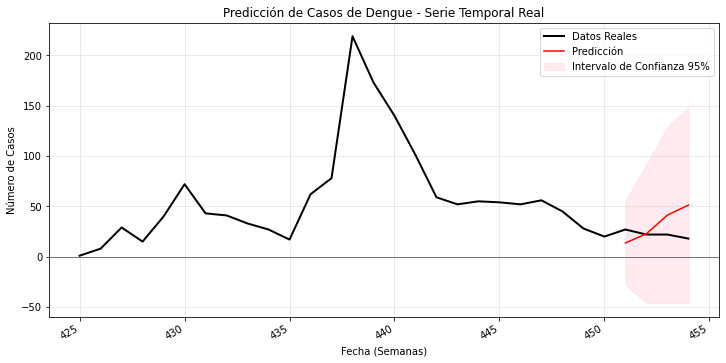

Error Absoluto Medio (MAE): 16.68 casos
Raíz del Error Cuadrático Medio (RMSE): 20.35 casos
Error Porcentual Absoluto Medio (MAPE): 81.39%


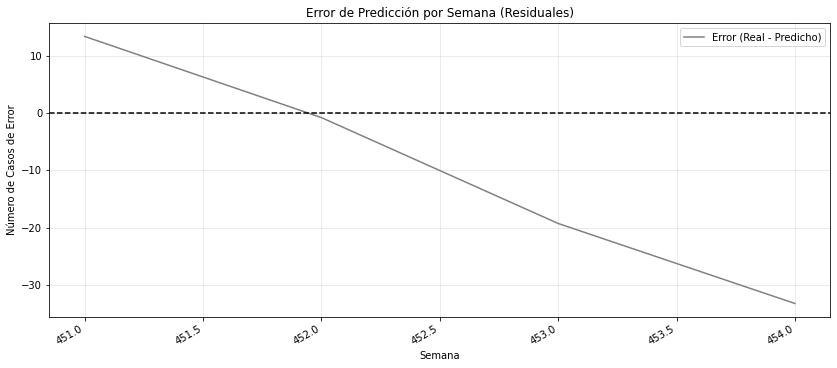

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(0, 1, 6), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


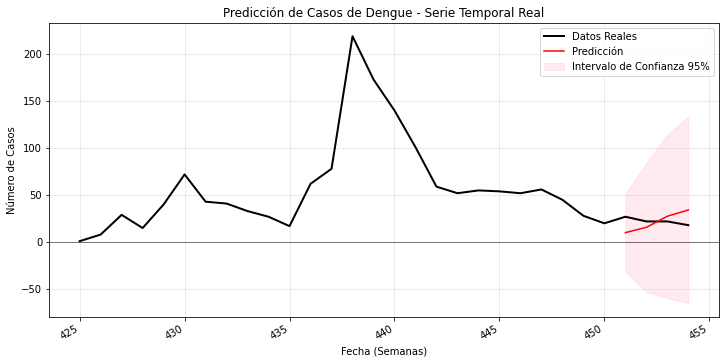

Error Absoluto Medio (MAE): 11.23 casos
Raíz del Error Cuadrático Medio (RMSE): 12.44 casos
Error Porcentual Absoluto Medio (MAPE): 51.59%


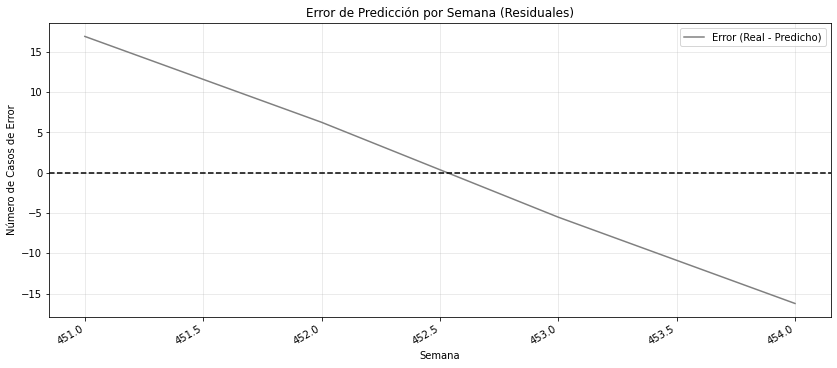

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(2, 1, 1), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Villa Clara

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Temperatura med_lag6'],
      dtype='object')


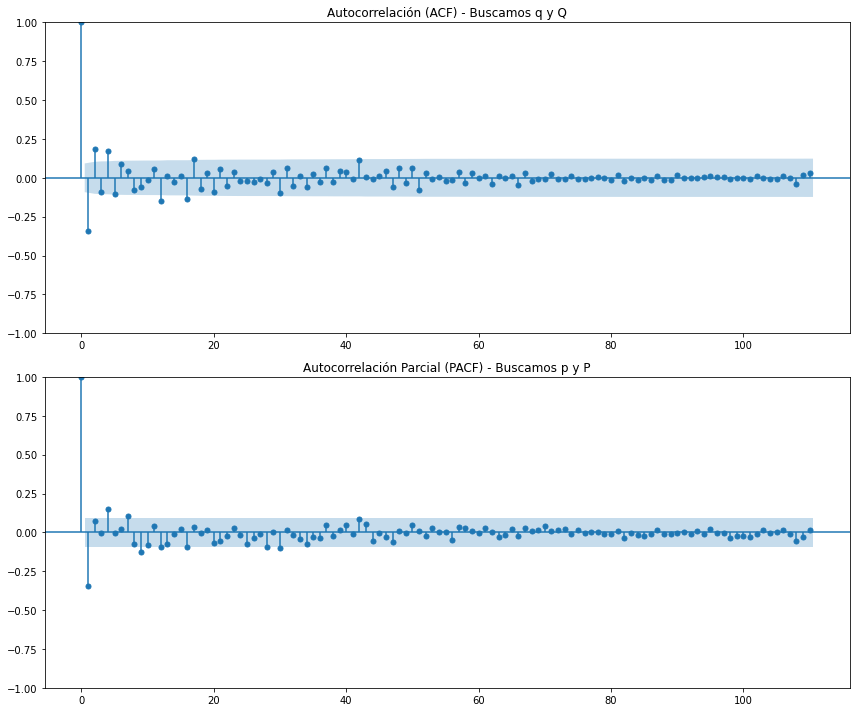

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Villa_Clara'

carpeta_salida = 'dataframes_con_lags'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [ ]:
import itertools
import statsmodels.api as sm

p =  [0,1,2,6]
q=[0,1,2,6]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[['Temperatura med', 'Humedad Relat', 'Precipitaciones','Temperatura med_lag6']]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 4921.745892221162
(0, 1, 0) (0, 0, 1, 52) 4084.355206453222
(0, 1, 0) (0, 1, 0, 52) 4463.379769484651
(0, 1, 0) (1, 0, 0, 52) 4093.20687365048
(0, 1, 0) (1, 0, 1, 52) 4085.231035752254
(0, 1, 0) (1, 1, 0, 52) 3711.708554535375
(0, 1, 0) (1, 1, 1, 52) 3674.9618865250513
(0, 1, 1) (0, 0, 0, 52) 4862.835580592191
(0, 1, 1) (0, 0, 1, 52) 4072.3530940795863
(0, 1, 1) (0, 1, 0, 52) 4433.786846818305
(0, 1, 1) (0, 1, 1, 52) 3689.990094131859
(0, 1, 1) (1, 0, 0, 52) 4091.0617373134537
(0, 1, 1) (1, 0, 1, 52) 4073.535274190156
(0, 1, 1) (1, 1, 0, 52) 3712.0397714197097


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 1) (1, 1, 1, 52) 3662.9244008844703
(0, 1, 2) (0, 0, 0, 52) 4837.8767811162015
(0, 1, 2) (0, 0, 1, 52) 4064.5254317944145
(0, 1, 2) (0, 1, 0, 52) 4414.8561502047
(0, 1, 2) (0, 1, 1, 52) 3680.0132265057764
(0, 1, 2) (1, 0, 0, 52) 4092.6648605941646


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 2) (1, 0, 1, 52) 4065.847343924621
(0, 1, 2) (1, 1, 0, 52) 3711.8408776849906


...

(6, 1, 6) (1, 0, 1, 52) 4030.9714677783513


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(6, 1, 6) (1, 1, 0, 52) 3639.1385947530043


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(6, 1, 6) (1, 1, 1, 52) 3625.4939904088515
Mejor SARIMA: ((2, 1, 6), (1, 1, 1, 52)) con AIC: 3597.269628942194


In [30]:
import itertools
import statsmodels.api as sm
import re
import ast

output_anterior = """
(0, 1, 0) (0, 0, 0, 52) 4921.745892221162
(0, 1, 0) (0, 0, 1, 52) 4084.355206453222
(0, 1, 0) (0, 1, 0, 52) 4463.379769484651
(0, 1, 0) (1, 0, 0, 52) 4093.20687365048
(0, 1, 0) (1, 0, 1, 52) 4085.231035752254
(0, 1, 0) (1, 1, 0, 52) 3711.708554535375
(0, 1, 0) (1, 1, 1, 52) 3674.9618865250513
(0, 1, 1) (0, 0, 0, 52) 4862.835580592191
(0, 1, 1) (0, 0, 1, 52) 4072.3530940795863
(0, 1, 1) (0, 1, 0, 52) 4433.786846818305
(0, 1, 1) (0, 1, 1, 52) 3689.990094131859
(0, 1, 1) (1, 0, 0, 52) 4091.0617373134537
(0, 1, 1) (1, 0, 1, 52) 4073.535274190156
(0, 1, 1) (1, 1, 0, 52) 3712.0397714197097
(0, 1, 1) (1, 1, 1, 52) 3662.9244008844703
(0, 1, 2) (0, 0, 0, 52) 4837.8767811162015
(0, 1, 2) (0, 0, 1, 52) 4064.5254317944145
(0, 1, 2) (0, 1, 0, 52) 4414.8561502047
(0, 1, 2) (0, 1, 1, 52) 3680.0132265057764
(0, 1, 2) (1, 0, 0, 52) 4092.6648605941646
(0, 1, 2) (1, 0, 1, 52) 4065.847343924621
(0, 1, 2) (1, 1, 0, 52) 3711.8408776849906
(0, 1, 2) (1, 1, 1, 52) 3654.6772719384267
(0, 1, 6) (0, 0, 0, 52) 4777.7132571220955
(0, 1, 6) (0, 0, 1, 52) 4017.098111844578
(0, 1, 6) (0, 1, 0, 52) 4364.889394697348
(0, 1, 6) (0, 1, 1, 52) 3636.601109524788
(0, 1, 6) (1, 0, 0, 52) 4082.15432376717
(0, 1, 6) (1, 0, 1, 52) 4018.3613576584403
(0, 1, 6) (1, 1, 0, 52) 3706.728996735277
(0, 1, 6) (1, 1, 1, 52) 3612.0260358478317
(1, 1, 0) (0, 0, 0, 52) 4861.958037823259
(1, 1, 0) (0, 0, 1, 52) 4081.751275018621
(1, 1, 0) (0, 1, 0, 52) 4440.456404378085
(1, 1, 0) (0, 1, 1, 52) 3699.612047568493
(1, 1, 0) (1, 0, 0, 52) 4081.4452758308657
(1, 1, 0) (1, 0, 1, 52) 4082.945119905281
(1, 1, 0) (1, 1, 0, 52) 3701.8918736841656
(1, 1, 0) (1, 1, 1, 52) 3671.9294774473155
(1, 1, 1) (0, 0, 0, 52) 4851.717569781644
(1, 1, 1) (0, 0, 1, 52) 4075.0011439315126
(1, 1, 1) (0, 1, 0, 52) 4430.524986524515
(1, 1, 1) (0, 1, 1, 52) 3688.2567500473087
(1, 1, 1) (1, 0, 0, 52) 4083.7385538155922
(1, 1, 1) (1, 0, 1, 52) 4076.2716724622046
(1, 1, 1) (1, 1, 0, 52) 3700.184175750937
(1, 1, 1) (1, 1, 1, 52) 3663.318866533048
(1, 1, 2) (0, 0, 0, 52) 4835.474942171074
(1, 1, 2) (0, 0, 1, 52) 4065.2360716032076
(1, 1, 2) (0, 1, 0, 52) 4412.64806091156
(1, 1, 2) (0, 1, 1, 52) 3678.0941374291774
(1, 1, 2) (1, 0, 0, 52) 4083.7898530493876
(1, 1, 2) (1, 0, 1, 52) 4065.8660905329502
(1, 1, 2) (1, 1, 0, 52) 3699.475463077608
(1, 1, 2) (1, 1, 1, 52) 3651.726532590934
(1, 1, 6) (0, 0, 0, 52) 4780.206072224276
(1, 1, 6) (0, 0, 1, 52) 4019.6507981548584
(1, 1, 6) (0, 1, 0, 52) 4366.893804881654
(1, 1, 6) (0, 1, 1, 52) 3638.702382651554
(1, 1, 6) (1, 0, 0, 52) 4075.2925621091426
(1, 1, 6) (1, 0, 1, 52) 4020.4873266578343
(1, 1, 6) (1, 1, 0, 52) 3700.655938967022
(1, 1, 6) (1, 1, 1, 52) 3611.2747747947824
(2, 1, 0) (0, 0, 0, 52) 4851.7718647389465
(2, 1, 0) (0, 0, 1, 52) 4083.7185248371206
(2, 1, 0) (0, 1, 0, 52) 4430.305382582297
(2, 1, 0) (0, 1, 1, 52) 3700.6117904975213
(2, 1, 0) (1, 0, 0, 52) 4073.9434872717493
(2, 1, 0) (1, 0, 1, 52) 4075.4486462176783
(2, 1, 0) (1, 1, 0, 52) 3692.7357822007843
(2, 1, 0) (1, 1, 1, 52) 3663.9254499710987
(2, 1, 1) (0, 0, 0, 52) 4853.806520950683
(2, 1, 1) (0, 0, 1, 52) 4072.9839047647065
(2, 1, 1) (0, 1, 0, 52) 4429.282638398759
(2, 1, 1) (0, 1, 1, 52) 3689.4745100128516
(2, 1, 1) (1, 0, 0, 52) 4072.265547791256
(2, 1, 1) (1, 0, 1, 52) 4073.602692331915
(2, 1, 1) (1, 1, 0, 52) 3690.94196209061
(2, 1, 1) (1, 1, 1, 52) 3661.257984415608
(2, 1, 2) (0, 0, 0, 52) 4836.599231009347
(2, 1, 2) (0, 0, 1, 52) 4061.88391875493
(2, 1, 2) (0, 1, 0, 52) 4414.4370756532435
(2, 1, 2) (0, 1, 1, 52) 3671.7947546241116
(2, 1, 2) (1, 0, 0, 52) 4053.6519298247886
(2, 1, 2) (1, 0, 1, 52) 4063.376021748327
(2, 1, 2) (1, 1, 0, 52) 3686.8479537057488
(2, 1, 2) (1, 1, 1, 52) 3653.421698051803
(2, 1, 6) (0, 0, 0, 52) 4763.528167112254
(2, 1, 6) (0, 0, 1, 52) 3989.448540000687
(2, 1, 6) (0, 1, 0, 52) 4361.520304786805
(2, 1, 6) (0, 1, 1, 52) 3622.3342972585097
(2, 1, 6) (1, 0, 0, 52) 4034.621824075527
(2, 1, 6) (1, 0, 1, 52) 3988.996838256571
(2, 1, 6) (1, 1, 0, 52) 3670.275943499876
(2, 1, 6) (1, 1, 1, 52) 3597.269628942194
(6, 1, 0) (0, 0, 0, 52) 4795.643391886999
(6, 1, 0) (0, 0, 1, 52) 4080.01139268571
(6, 1, 0) (0, 1, 0, 52) 4380.825353855095
(6, 1, 0) (0, 1, 1, 52) 3699.6291444918697
(6, 1, 0) (1, 0, 0, 52) 4031.339248823522
(6, 1, 0) (1, 0, 1, 52) 4033.0356553056936
(6, 1, 0) (1, 1, 0, 52) 3650.9140512441995
(6, 1, 0) (1, 1, 1, 52) 3625.286188053119
(6, 1, 1) (0, 0, 0, 52) 4796.791803922173
(6, 1, 1) (0, 0, 1, 52) 4072.696321735181
(6, 1, 1) (0, 1, 0, 52) 4382.740447992066
(6, 1, 1) (0, 1, 1, 52) 3692.275359113555
(6, 1, 1) (1, 0, 0, 52) 4033.78973325977
(6, 1, 1) (1, 0, 1, 52) 4035.4043324921463
(6, 1, 1) (1, 1, 0, 52) 3653.31631414999
(6, 1, 1) (1, 1, 1, 52) 3624.806238035872
(6, 1, 2) (0, 0, 0, 52) 4792.794569699603
(6, 1, 2) (0, 0, 1, 52) 4030.240986850126
(6, 1, 2) (0, 1, 0, 52) 4368.47582708114
(6, 1, 2) (0, 1, 1, 52) 3670.9460722814038
(6, 1, 2) (1, 0, 0, 52) 4001.4488482454544
(6, 1, 2) (1, 0, 1, 52) 4002.9827443881463
(6, 1, 2) (1, 1, 0, 52) 3633.985241111818
(6, 1, 2) (1, 1, 1, 52) 3641.6150449432
(6, 1, 6) (0, 0, 0, 52) 4772.6007679673885
(6, 1, 6) (0, 0, 1, 52) 4013.7295892037137
(6, 1, 6) (0, 1, 0, 52) 4360.247070769046
(6, 1, 6) (0, 1, 1, 52) 3628.297295195385
(6, 1, 6) (1, 0, 0, 52) 4037.63461989922
(6, 1, 6) (1, 0, 1, 52) 4030.9714677783513
(6, 1, 6) (1, 1, 0, 52) 3639.1385947530043
(6, 1, 6) (1, 1, 1, 52) 3625.4939904088515
"""

pattern = re.compile(r'\((.*?)\)\s\((.*?)\)\s([\d.]+)')

resultados_anteriores = {}
for line in output_anterior.strip().split('\n'):
    match = pattern.search(line)
    if match:

        order_str = match.group(1)
        seasonal_order_str = match.group(2)
        aic_str = match.group(3)
        
        order = ast.literal_eval(f"({order_str})")
        seasonal_order = ast.literal_eval(f"({seasonal_order_str})") 
        
        aic = float(aic_str)
        
        # Guardar en el diccionario
        resultados_anteriores[(order, seasonal_order)] = aic

print(f"Se cargaron {len(resultados_anteriores)} resultados anteriores.")

p =  [0,1,2]
q=[0,1,2,3,4]

d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]

y = df["Casos_Dengue"]
exog_vars =df[['Temperatura med', 'Humedad Relat', 'Precipitaciones','Temperatura med_lag6']]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

if resultados_anteriores:
    mejores_params_anteriores = min(resultados_anteriores, key=resultados_anteriores.get)
    mejor_aic = resultados_anteriores[mejores_params_anteriores]
    mejores_params = mejores_params_anteriores
    print(f"Reanudando búsqueda. Mejor resultado anterior: {mejores_params} con AIC: {mejor_aic}")
else:
    mejores_params = None
    mejor_aic = float("inf")
    print("Iniciando nueva búsqueda.")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        
        if (param, param_seasonal) in resultados_anteriores:
            continue
            
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(f"  {param} {param_seasonal} - AIC: {results.aic}")

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                print(f"*** ¡NUEVO MEJOR! {mejores_params} con AIC: {mejor_aic} ***")
                
        except Exception as e:
            continue

print("\n--- BÚSQUEDA FINALIZADA ---")
print(f"Mejor SARIMA encontrado: {mejores_params} con AIC: {mejor_aic}")

Se cargaron 127 resultados anteriores.
Reanudando búsqueda. Mejor resultado anterior: ((2, 1, 6), (1, 1, 1, 52)) con AIC: 3597.269628942194
  (0, 1, 0) (0, 1, 1, 52) - AIC: 3700.6041850865786


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  (0, 1, 3) (0, 0, 0, 52) - AIC: 4830.22458087264
  (0, 1, 3) (0, 0, 1, 52) - AIC: 4050.8998675608414


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  (0, 1, 3) (0, 1, 0, 52) - AIC: 4405.620313969264


...

  (2, 1, 4) (1, 0, 1, 52) - AIC: 4045.6742445588475


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  (2, 1, 4) (1, 1, 0, 52) - AIC: 3694.6822013892497


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  (2, 1, 4) (1, 1, 1, 52) - AIC: 3638.256012418692

--- BÚSQUEDA FINALIZADA ---
Mejor SARIMA encontrado: ((2, 1, 6), (1, 1, 1, 52)) con AIC: 3597.269628942194


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


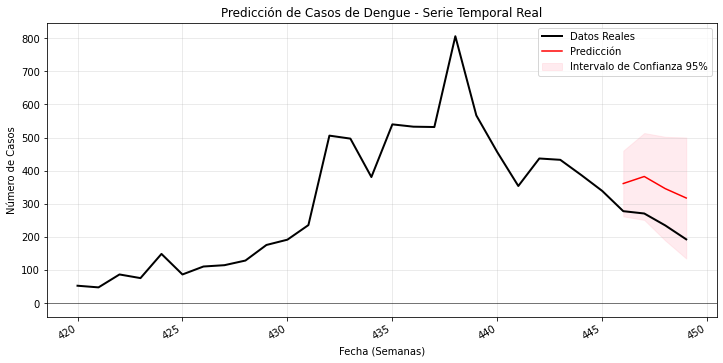

Error Absoluto Medio (MAE): 107.72 casos
Raíz del Error Cuadrático Medio (RMSE): 108.77 casos
Error Porcentual Absoluto Medio (MAPE): 45.78%


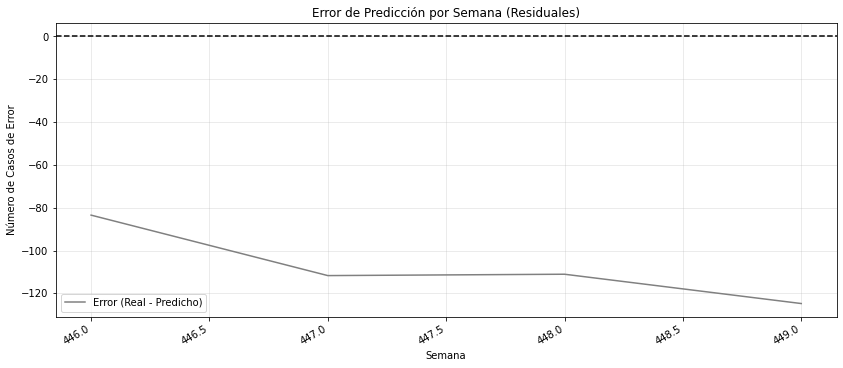

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(0, 1, 4), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


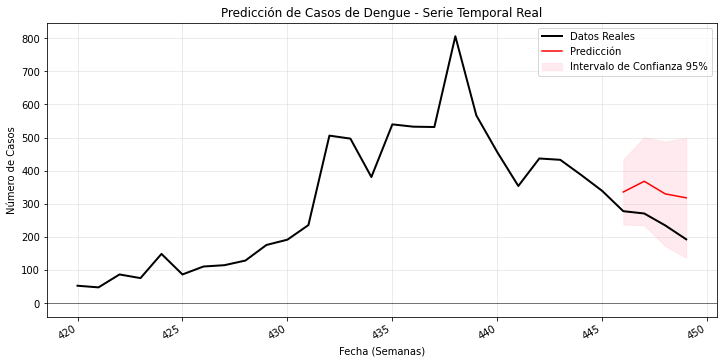

Error Absoluto Medio (MAE): 93.90 casos
Raíz del Error Cuadrático Medio (RMSE): 96.91 casos
Error Porcentual Absoluto Medio (MAPE): 40.53%


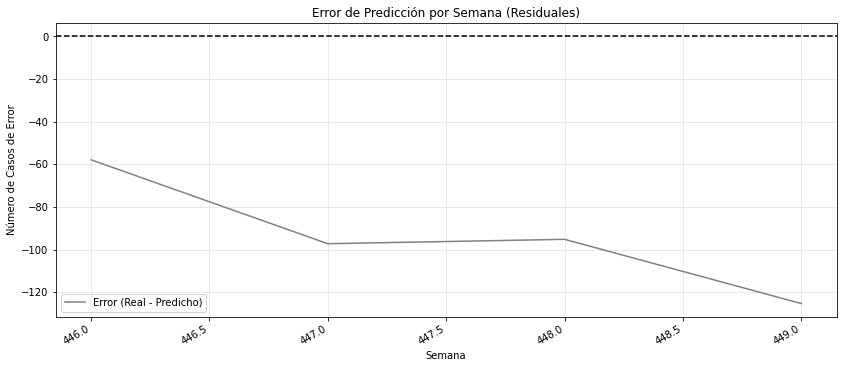

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(1, 1, 2), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Santi Spiritus

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


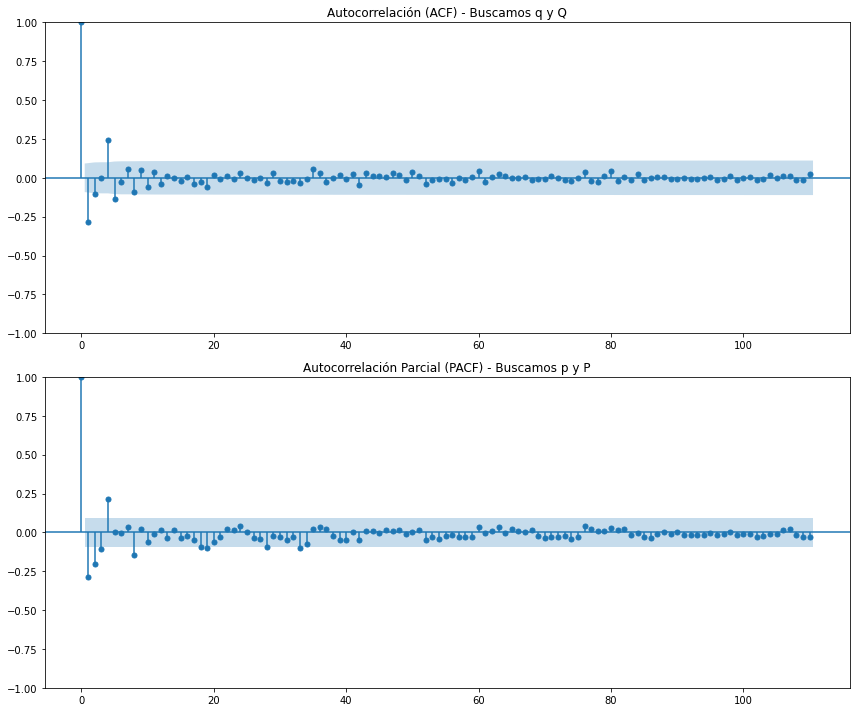

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Sancti_Spíritus'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [ ]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[["Temp_Med","Hum_Rel","Precip"]]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 4714.477675159833
(0, 1, 0) (0, 0, 1, 52) 3879.625066952657
(0, 1, 0) (0, 1, 0, 52) 4270.424179344391
(0, 1, 0) (0, 1, 1, 52) 3491.2725677656445
(0, 1, 0) (1, 0, 0, 52) 3888.7821424425406
(0, 1, 0) (1, 0, 1, 52) 3881.5327115498685
(0, 1, 0) (1, 1, 0, 52) 3499.046650205618
(0, 1, 0) (1, 1, 1, 52) 3469.777564909973
(0, 1, 1) (0, 0, 0, 52) 4642.188111416674
(0, 1, 1) (0, 0, 1, 52) 3866.9476099237418
(0, 1, 1) (0, 1, 0, 52) 4219.260565189511
(0, 1, 1) (0, 1, 1, 52) 3479.906727192274
(0, 1, 1) (1, 0, 0, 52) 3884.9003373497153
(0, 1, 1) (1, 0, 1, 52) 3868.8796292797037
(0, 1, 1) (1, 1, 0, 52) 3496.7690361447612
(0, 1, 1) (1, 1, 1, 52) 3457.9813897070335
(0, 1, 2) (0, 0, 0, 52) 4633.692650690613
(0, 1, 2) (0, 0, 1, 52) 3859.9905052298755
(0, 1, 2) (0, 1, 0, 52) 4210.878119159481
(0, 1, 2) (0, 1, 1, 52) 3472.449711993787
(0, 1, 2) (1, 0, 0, 52) 3886.659524107283
(0, 1, 2) (1, 0, 1, 52) 3861.9193291057836
(0, 1, 2) (1, 1, 0, 52) 3498.347103375606
(0, 1, 2) (1, 1, 1, 52) 

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(1, 1, 1) (1, 1, 1, 52) 3462.8962244967656
(1, 1, 2) (0, 0, 0, 52) 4635.005116017144
(1, 1, 2) (0, 0, 1, 52) 3861.968764957088


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(1, 1, 2) (0, 1, 0, 52) 4212.36627012207
(1, 1, 2) (0, 1, 1, 52) 3474.449375643521


...

(2, 1, 2) (1, 0, 1, 52) 3869.411190838019


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 0, 52) 3481.3259725395355


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 1, 52) 3455.1779670226283
Mejor SARIMA: ((0, 1, 2), (1, 1, 1, 52)) con AIC: 3450.5412831189815


In [33]:
import itertools
import statsmodels.api as sm
import re
import ast

output_anterior = """
(0, 1, 0) (0, 0, 0, 52) 4714.477675159833
(0, 1, 0) (0, 0, 1, 52) 3879.625066952657
(0, 1, 0) (0, 1, 0, 52) 4270.424179344391
(0, 1, 0) (0, 1, 1, 52) 3491.2725677656445
(0, 1, 0) (1, 0, 0, 52) 3888.7821424425406
(0, 1, 0) (1, 0, 1, 52) 3881.5327115498685
(0, 1, 0) (1, 1, 0, 52) 3499.046650205618
(0, 1, 0) (1, 1, 1, 52) 3469.777564909973
(0, 1, 1) (0, 0, 0, 52) 4642.188111416674
(0, 1, 1) (0, 0, 1, 52) 3866.9476099237418
(0, 1, 1) (0, 1, 0, 52) 4219.260565189511
(0, 1, 1) (0, 1, 1, 52) 3479.906727192274
(0, 1, 1) (1, 0, 0, 52) 3884.9003373497153
(0, 1, 1) (1, 0, 1, 52) 3868.8796292797037
(0, 1, 1) (1, 1, 0, 52) 3496.7690361447612
(0, 1, 1) (1, 1, 1, 52) 3457.9813897070335
(0, 1, 2) (0, 0, 0, 52) 4633.692650690613
(0, 1, 2) (0, 0, 1, 52) 3859.9905052298755
(0, 1, 2) (0, 1, 0, 52) 4210.878119159481
(0, 1, 2) (0, 1, 1, 52) 3472.449711993787
(0, 1, 2) (1, 0, 0, 52) 3886.659524107283
(0, 1, 2) (1, 0, 1, 52) 3861.9193291057836
(0, 1, 2) (1, 1, 0, 52) 3498.347103375606
(0, 1, 2) (1, 1, 1, 52) 3450.5412831189815
(1, 1, 0) (0, 0, 0, 52) 4672.894557610523
(1, 1, 1) (0, 1, 1, 52) 3483.7879322090384
(1, 1, 1) (1, 0, 0, 52) 3884.3225743487765
(1, 1, 1) (1, 0, 1, 52) 3876.9658635688916
(1, 1, 1) (1, 1, 0, 52) 3491.702487248117
(1, 1, 1) (1, 1, 1, 52) 3462.8962244967656
(1, 1, 2) (0, 0, 0, 52) 4635.005116017144
(1, 1, 2) (0, 0, 1, 52) 3861.968764957088
(1, 1, 2) (0, 1, 0, 52) 4212.36627012207
(1, 1, 2) (0, 1, 1, 52) 3474.449375643521
(1, 1, 2) (1, 0, 0, 52) 3879.886288729157
(1, 1, 2) (1, 0, 1, 52) 3863.896200352099
(1, 1, 2) (1, 1, 0, 52) 3491.2405207808547
(1, 1, 2) (1, 1, 1, 52) 3452.1661229774904
(2, 1, 0) (0, 0, 0, 52) 4640.782704075304
(2, 1, 0) (0, 0, 1, 52) 3877.6387106700918
(2, 1, 0) (0, 1, 0, 52) 4217.777883466054
(2, 1, 0) (0, 1, 1, 52) 3490.684300079507
(2, 1, 0) (1, 0, 0, 52) 3869.301330283433
(2, 1, 0) (1, 0, 1, 52) 3870.806889888941
(2, 1, 0) (1, 1, 0, 52) 3480.1490966849146
(2, 1, 0) (1, 1, 1, 52) 3459.4270223029903
(2, 1, 1) (0, 0, 0, 52) 4639.156066947087
(2, 1, 1) (0, 0, 1, 52) 3870.711452949757
(2, 1, 1) (0, 1, 0, 52) 4218.585997940272
(2, 1, 1) (0, 1, 1, 52) 3479.8671611335963
(2, 1, 1) (1, 0, 0, 52) 3871.129957423799
(2, 1, 1) (1, 0, 1, 52) 3872.62983965065
(2, 1, 1) (1, 1, 0, 52) 3479.2838561227163
(2, 1, 1) (1, 1, 1, 52) 3458.3922550738616
(2, 1, 2) (0, 0, 0, 52) 4622.091902015351
(2, 1, 2) (0, 0, 1, 52) 3867.4628540840354
(2, 1, 2) (0, 1, 0, 52) 4200.790110946902
(2, 1, 2) (0, 1, 1, 52) 3472.9929666737225
(2, 1, 2) (1, 0, 0, 52) 3876.4824533616165
(2, 1, 2) (1, 0, 1, 52) 3869.411190838019
(2, 1, 2) (1, 1, 0, 52) 3481.3259725395355
(2, 1, 2) (1, 1, 1, 52) 3455.1779670226283
"""

pattern = re.compile(r'\((.*?)\)\s\((.*?)\)\s([\d.]+)')

resultados_anteriores = {}
for line in output_anterior.strip().split('\n'):
    match = pattern.search(line)
    if match:

        order_str = match.group(1)
        seasonal_order_str = match.group(2)
        aic_str = match.group(3)
        
        order = ast.literal_eval(f"({order_str})")
        seasonal_order = ast.literal_eval(f"({seasonal_order_str})") 
        
        aic = float(aic_str)
        
        # Guardar en el diccionario
        resultados_anteriores[(order, seasonal_order)] = aic

print(f"Se cargaron {len(resultados_anteriores)} resultados anteriores.")

p =  [0,1,2,3,4]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]

y = df["Casos_Dengue"]
exog_vars =df[["Temp_Med","Hum_Rel","Precip"]]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

if resultados_anteriores:
    mejores_params_anteriores = min(resultados_anteriores, key=resultados_anteriores.get)
    mejor_aic = resultados_anteriores[mejores_params_anteriores]
    mejores_params = mejores_params_anteriores
    print(f"Reanudando búsqueda. Mejor resultado anterior: {mejores_params} con AIC: {mejor_aic}")
else:
    mejores_params = None
    mejor_aic = float("inf")
    print("Iniciando nueva búsqueda.")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        
        if (param, param_seasonal) in resultados_anteriores:
            continue
            
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(f"  {param} {param_seasonal} - AIC: {results.aic}")

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                print(f"*** ¡NUEVO MEJOR! {mejores_params} con AIC: {mejor_aic} ***")
                
        except Exception as e:
            continue

print("\n--- BÚSQUEDA FINALIZADA ---")
print(f"Mejor SARIMA encontrado: {mejores_params} con AIC: {mejor_aic}")

Se cargaron 62 resultados anteriores.
Reanudando búsqueda. Mejor resultado anterior: ((0, 1, 2), (1, 1, 1, 52)) con AIC: 3450.5412831189815
  (1, 1, 0) (0, 0, 1, 52) - AIC: 3876.0501956394783
  (1, 1, 0) (0, 1, 0, 52) - AIC: 4240.6929692842195
  (1, 1, 0) (0, 1, 1, 52) - AIC: 3489.3724005712693
  (1, 1, 0) (1, 0, 0, 52) - AIC: 3876.4933946409774
  (1, 1, 0) (1, 0, 1, 52) - AIC: 3877.973763380862
  (1, 1, 0) (1, 1, 0, 52) - AIC: 3488.0478024185713
  (1, 1, 0) (1, 1, 1, 52) - AIC: 3467.188814342634
  (1, 1, 1) (0, 0, 0, 52) - AIC: 4643.508978728631
  (1, 1, 1) (0, 0, 1, 52) - AIC: 3875.023430838843
  (1, 1, 1) (0, 1, 0, 52) - AIC: 4220.823031689758
  (3, 1, 0) (0, 0, 0, 52) - AIC: 4623.777691581061
  (3, 1, 0) (0, 0, 1, 52) - AIC: 3878.855459576269
  (3, 1, 0) (0, 1, 0, 52) - AIC: 4206.7023406925155
  (3, 1, 0) (0, 1, 1, 52) - AIC: 3492.2910475756835
  (3, 1, 0) (1, 0, 0, 52) - AIC: 3861.7652471066463


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  (3, 1, 0) (1, 0, 1, 52) - AIC: 3863.266064464577
  (3, 1, 0) (1, 1, 0, 52) - AIC: 3472.6350349949407
  (3, 1, 0) (1, 1, 1, 52) - AIC: 3451.41956098457
  (3, 1, 1) (0, 0, 0, 52) - AIC: 4616.764243850383
  (3, 1, 1) (0, 0, 1, 52) - AIC: 3871.7890030918516


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  (3, 1, 1) (0, 1, 0, 52) - AIC: 4202.333320721888
  (3, 1, 1) (0, 1, 1, 52) - AIC: 3481.733601708266


...

  (4, 1, 2) (1, 0, 1, 52) - AIC: 3858.8706052691896


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  (4, 1, 2) (1, 1, 0, 52) - AIC: 3466.1373695190123


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  (4, 1, 2) (1, 1, 1, 52) - AIC: 3449.1477499138164

--- BÚSQUEDA FINALIZADA ---
Mejor SARIMA encontrado: ((4, 1, 0), (1, 1, 1, 52)) con AIC: 3441.4695542353084


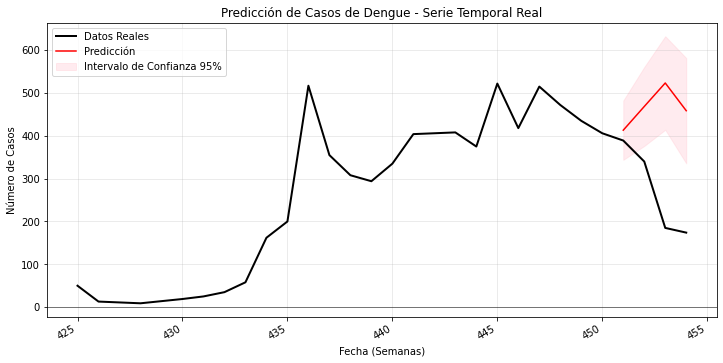

Error Absoluto Medio (MAE): 193.92 casos
Raíz del Error Cuadrático Medio (RMSE): 230.55 casos
Error Porcentual Absoluto Medio (MAPE): 97.62%


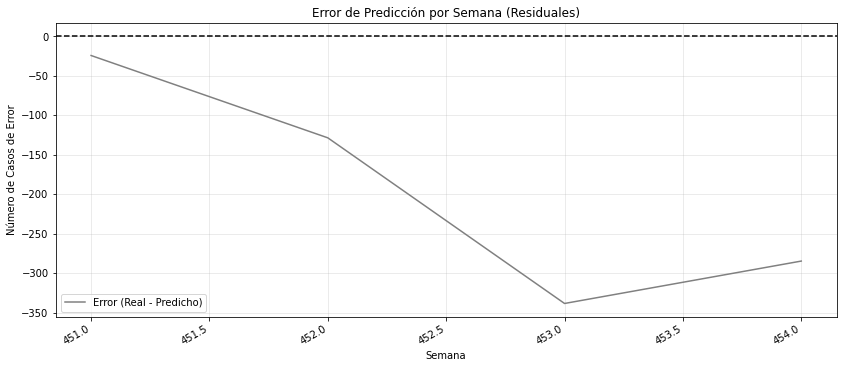

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(4, 1, 0), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

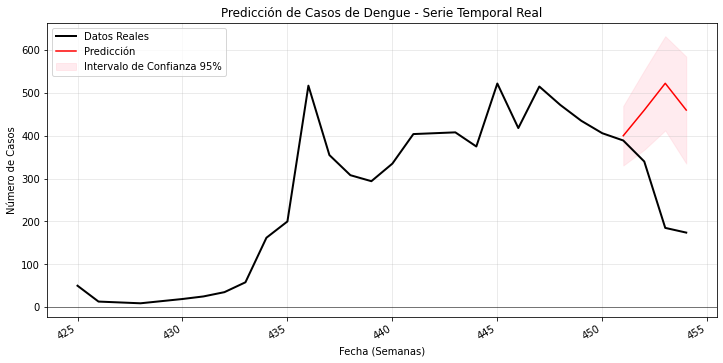

Error Absoluto Medio (MAE): 188.63 casos
Raíz del Error Cuadrático Medio (RMSE): 229.24 casos
Error Porcentual Absoluto Medio (MAPE): 96.23%


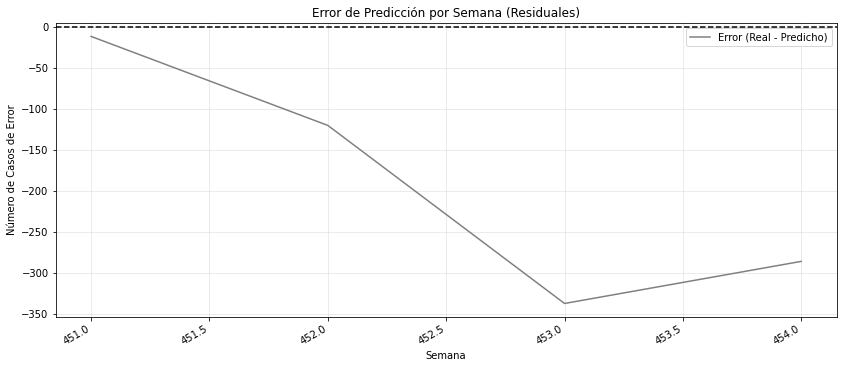

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(0, 1, 2), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Ciego de Avila

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


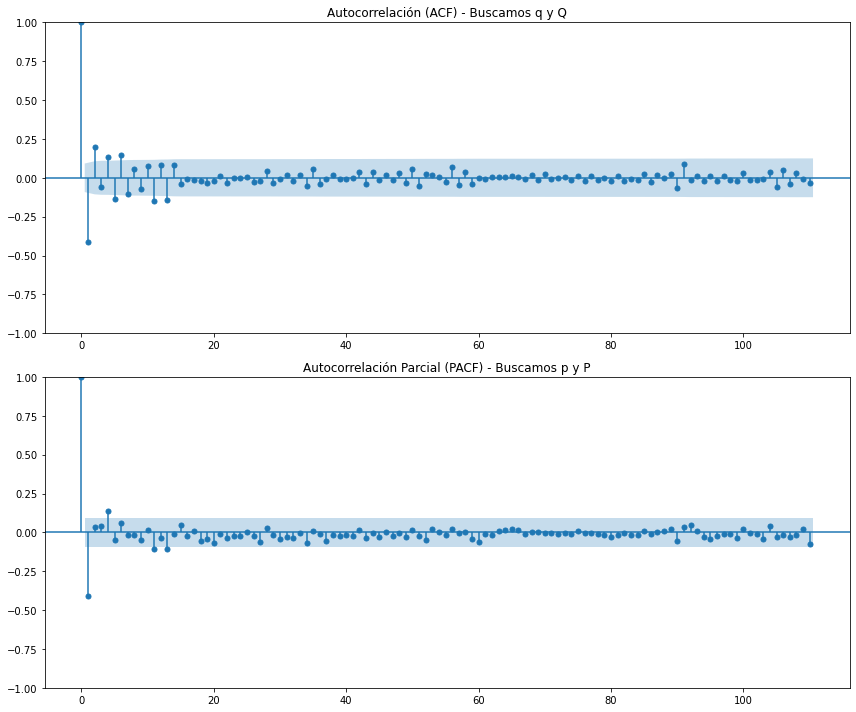

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Ciego_de_Ávila'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [36]:
import itertools
import statsmodels.api as sm

p =  [0,1]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[["Temp_Med","Hum_Rel","Precip"]]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 4638.406502278562
(0, 1, 0) (0, 0, 1, 52) 4003.528347006053
(0, 1, 0) (0, 1, 0, 52) 4278.462960480829
(0, 1, 0) (0, 1, 1, 52) 3573.8196548087953
(0, 1, 0) (1, 0, 0, 52) 4012.6250659755383
(0, 1, 0) (1, 0, 1, 52) 4005.4784947486955
(0, 1, 0) (1, 1, 0, 52) 3616.588838442465
(0, 1, 0) (1, 1, 1, 52) 3553.5726706133228
(0, 1, 1) (0, 0, 0, 52) 4564.663780899096
(0, 1, 1) (0, 0, 1, 52) 3954.970091671129
(0, 1, 1) (0, 1, 0, 52) 4226.761150263842
(0, 1, 1) (0, 1, 1, 52) 3531.902052797709
(0, 1, 1) (1, 0, 0, 52) 3972.9181682556246
(0, 1, 1) (1, 0, 1, 52) 3956.9404745479255
(0, 1, 1) (1, 1, 0, 52) 3590.8379015079813
(0, 1, 1) (1, 1, 1, 52) 3513.956121198982
(0, 1, 2) (0, 0, 0, 52) 4531.217639594577
(0, 1, 2) (0, 0, 1, 52) 3914.951060129939
(0, 1, 2) (0, 1, 0, 52) 4198.395374208709
(0, 1, 2) (0, 1, 1, 52) 3502.7058592814074
(0, 1, 2) (1, 0, 0, 52) 3941.5804154384205
(0, 1, 2) (1, 0, 1, 52) 3916.926843024591
(0, 1, 2) (1, 1, 0, 52) 3567.650528987388
(0, 1, 2) (1, 1, 1, 52) 3

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(1, 1, 1) (1, 0, 0, 52) 3929.7358365389323


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(1, 1, 1) (1, 0, 1, 52) 3922.836828281194
(1, 1, 1) (1, 1, 0, 52) 3566.4698865308237
(1, 1, 1) (1, 1, 1, 52) 3496.498661282874
(1, 1, 2) (0, 0, 0, 52) 4531.7864853258125


...

(1, 1, 2) (1, 0, 0, 52) 3933.958703584177


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(1, 1, 2) (1, 0, 1, 52) 3918.200197440876
(1, 1, 2) (1, 1, 0, 52) 3555.0389259797394


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(1, 1, 2) (1, 1, 1, 52) 3484.137352408088
Mejor SARIMA: ((0, 1, 2), (1, 1, 1, 52)) con AIC: 3482.5000743157816


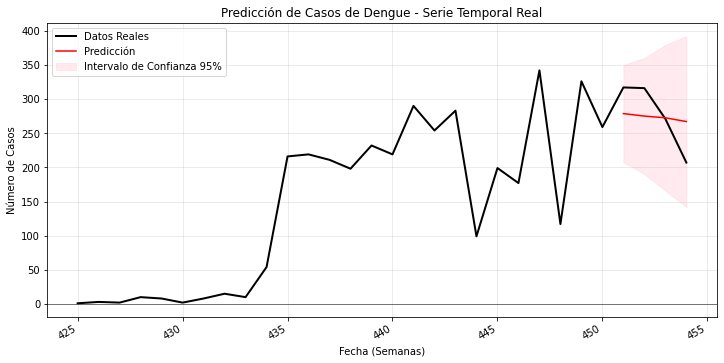

Error Absoluto Medio (MAE): 35.21 casos
Raíz del Error Cuadrático Medio (RMSE): 41.09 casos
Error Porcentual Absoluto Medio (MAPE): 13.65%


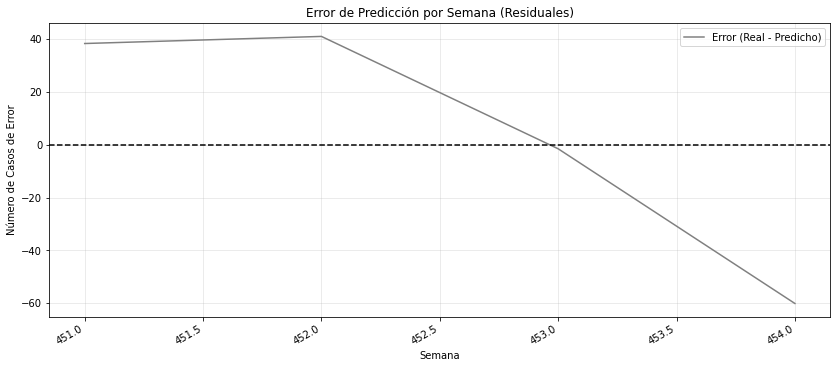

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(0, 1, 2), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Camaguey

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Precipitaciones_lag5', 'Precipitaciones_lag9'],
      dtype='object')


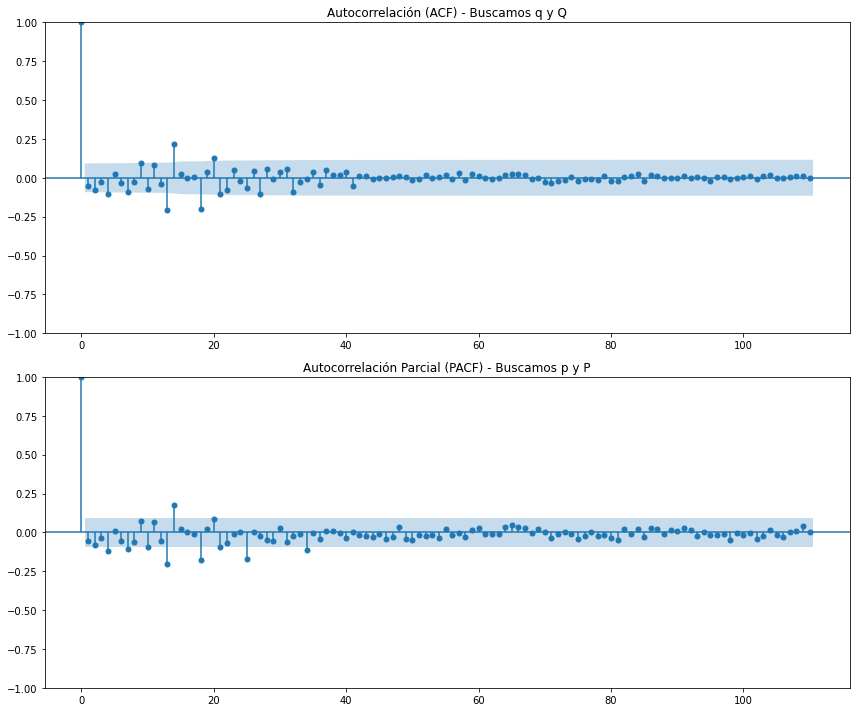

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Camagüey'

carpeta_salida = 'dataframes_con_lags'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [ ]:
import itertools
import statsmodels.api as sm

p =  [0,1,2,3,4]
q=[0,1,2,3,4]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[[ 'Temperatura med', 'Humedad Relat', 'Precipitaciones','Precipitaciones_lag5', 'Precipitaciones_lag9']]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 5209.073735997522
(0, 1, 0) (0, 0, 1, 52) 4218.938942572317
(0, 1, 0) (0, 1, 0, 52) 4708.081508721184


In [ ]:
"""(0, 1, 0) (0, 0, 0, 52) 5209.073736005525
(0, 1, 0) (0, 0, 1, 52) 4218.938942603392
(0, 1, 0) (0, 1, 0, 52) 4708.081508720847
(0, 1, 0) (0, 1, 1, 52) 3814.6290664382886
(0, 1, 0) (1, 0, 0, 52) 4228.910476093805
(0, 1, 0) (1, 0, 1, 52) 4220.938488858712
(0, 1, 0) (1, 1, 0, 52) 3826.3080903992714
(0, 1, 0) (1, 1, 1, 52) 3773.130070028952
(0, 1, 1) (0, 0, 0, 52) 5190.650506053762
(0, 1, 1) (0, 0, 1, 52) 4200.440337105171
(0, 1, 1) (0, 1, 0, 52) 4692.76750991152
(0, 1, 1) (0, 1, 1, 52) 3797.4753976998054
(0, 1, 1) (1, 0, 0, 52) 4220.34204010438
(0, 1, 1) (1, 0, 1, 52) 4202.462194481125
(0, 1, 1) (1, 1, 0, 52) 3820.8783879903194
(0, 1, 1) (1, 1, 1, 52) 3757.6484477538406
(0, 1, 2) (0, 0, 0, 52) 5175.862735605906
(0, 1, 2) (0, 0, 1, 52) 4189.110991249887
(0, 1, 2) (0, 1, 0, 52) 4682.804163389939
(0, 1, 2) (0, 1, 1, 52) 3782.2076427725633
(0, 1, 2) (1, 0, 0, 52) 4219.004794013558
(0, 1, 2) (1, 0, 1, 52) 4191.116798307528
(0, 1, 2) (1, 1, 0, 52) 3814.7098913123864
(0, 1, 2) (1, 1, 1, 52) 3745.1631933554927
(0, 1, 3) (0, 0, 0, 52) 5165.373852231478
(0, 1, 3) (0, 0, 1, 52) 4176.302443442135
(0, 1, 3) (0, 1, 0, 52) 4672.875389959802
(0, 1, 3) (0, 1, 1, 52) 3767.438495754006
(0, 1, 3) (1, 0, 0, 52) 4216.4047009541455
(0, 1, 3) (1, 0, 1, 52) 4178.305913172984
(0, 1, 3) (1, 1, 0, 52) 3808.8859584769666
(0, 1, 3) (1, 1, 1, 52) 3731.871386699633
(0, 1, 4) (0, 0, 0, 52) 5149.849664228719
(0, 1, 4) (0, 0, 1, 52) 4168.417038963125
(0, 1, 4) (0, 1, 0, 52) 4657.63149136599
(0, 1, 4) (0, 1, 1, 52) 3756.898458076614
(0, 1, 4) (1, 0, 0, 52) 4218.259983355678
(0, 1, 4) (1, 0, 1, 52) 4170.405462662742
(0, 1, 4) (1, 1, 0, 52) 3809.967707781643
(0, 1, 4) (1, 1, 1, 52) 3723.578478560691
(1, 1, 0) (0, 0, 0, 52) 5208.193709219835
(1, 1, 0) (0, 0, 1, 52) 4208.939817359349
(1, 1, 0) (0, 1, 0, 52) 4709.245762154981
(1, 1, 0) (0, 1, 1, 52) 3807.1887701786086
(1, 1, 0) (1, 0, 0, 52) 4209.354867029047
(1, 1, 0) (1, 0, 1, 52) 4210.936986828483
(1, 1, 0) (1, 1, 0, 52) 3806.1458074227485
(1, 1, 0) (1, 1, 1, 52) 3768.043904275556
(1, 1, 1) (0, 0, 0, 52) 5174.678786066292
(1, 1, 1) (0, 0, 1, 52) 4201.040781322165
(1, 1, 1) (0, 1, 0, 52) 4676.9938262881315
(1, 1, 1) (0, 1, 1, 52) 3810.8800681565076
(1, 1, 1) (1, 0, 0, 52) 4211.237591716379
(1, 1, 1) (1, 0, 1, 52) 4203.179571390199
(1, 1, 1) (1, 1, 0, 52) 3825.3954874146075
(1, 1, 1) (1, 1, 1, 52) 3762.652818310812
(1, 1, 2) (0, 0, 0, 52) 5166.914234707004
(1, 1, 2) (0, 0, 1, 52) 4189.420715511478
(1, 1, 2) (0, 1, 0, 52) 4667.34441541343
(1, 1, 2) (0, 1, 1, 52) 3786.791650902726
(1, 1, 2) (1, 0, 0, 52) 4209.763587077579
(1, 1, 2) (1, 0, 1, 52) 4191.477566070095
(1, 1, 2) (1, 1, 0, 52) 3809.2803111068824
(1, 1, 2) (1, 1, 1, 52) 3761.5305877269357
(1, 1, 3) (0, 0, 0, 52) 5156.798964331272
(1, 1, 3) (0, 0, 1, 52) 4178.22672435656
(1, 1, 3) (0, 1, 0, 52) 4657.970067275027
(1, 1, 3) (0, 1, 1, 52) 3768.345012917268
(1, 1, 3) (1, 0, 0, 52) 4208.563784922097
(1, 1, 3) (1, 0, 1, 52) 4178.082966739123
(1, 1, 3) (1, 1, 0, 52) 3798.9101258098544
(1, 1, 3) (1, 1, 1, 52) 3741.414057448676
(1, 1, 4) (0, 0, 0, 52) 5147.48851253810
(1, 1, 4) (0, 0, 1, 52) 4168.100448521721
(1, 1, 4) (0, 1, 0, 52) 4647.96203574661
(1, 1, 4) (0, 1, 1, 52) 3755.1460040721495
(1, 1, 4) (1, 0, 0, 52) 4208.069576630692
(1, 1, 4) (1, 0, 1, 52) 4170.1616490113765
(1, 1, 4) (1, 1, 0, 52) 3797.314486109296
(1, 1, 4) (1, 1, 1, 52) 3731.5280278463915
(2, 1, 0) (0, 0, 0, 52) 5189.390733851304
(2, 1, 0) (0, 0, 1, 52) 4210.637443979374
(2, 1, 0) (0, 1, 0, 52) 4694.477132850221
(2, 1, 0) (0, 1, 1, 52) 3808.0916607183253
(2, 1, 0) (1, 0, 0, 52) 4201.321698344432
(2, 1, 0) (1, 0, 1, 52) 4202.872845440035
(2, 1, 0) (1, 1, 0, 52) 3798.518706420599
(2, 1, 0) (1, 1, 1, 52) 3758.132566534159
(2, 1, 1) (0, 0, 0, 52) 5176.759108323371
(2, 1, 1) (0, 0, 1, 52) 4198.343897857856
(2, 1, 1) (0, 1, 0, 52) 4678.844327552426
(2, 1, 1) (0, 1, 1, 52) 3793.815031419646
(2, 1, 1) (1, 0, 0, 52) 4202.320788176069
(2, 1, 1) (1, 0, 1, 52) 4200.343680535445
(2, 1, 1) (1, 1, 0, 52) 3795.410580396154
(2, 1, 1) (1, 1, 1, 52) 3768.043834279032
(2, 1, 2) (0, 0, 0, 52) 5170.495004999988
(2, 1, 2) (0, 0, 1, 52) 4183.215392879016
(2, 1, 2) (0, 1, 0, 52) 4669.47435059516
(2, 1, 2) (0, 1, 1, 52) 3781.8969626866183
(2, 1, 2) (1, 0, 0, 52) 4248.453704123486
(2, 1, 2) (1, 0, 1, 52) 4234.986925111889
(2, 1, 2) (1, 1, 0, 52) 3801.9895162036905
(2, 1, 2) (1, 1, 1, 52) 3748.1713220663532
(2, 1, 3) (0, 0, 0, 52) 5158.437836830814
(2, 1, 3) (0, 0, 1, 52) 4218.213032895573
(2, 1, 3) (0, 1, 0, 52) 4660.116839122206
(2, 1, 3) (0, 1, 1, 52) 3766.617136946718
(2, 1, 3) (1, 0, 0, 52) 4220.743071685275
(2, 1, 3) (1, 0, 1, 52) 4232.135475073947
(2, 1, 3) (1, 1, 0, 52) 3821.798230098619
(2, 1, 3) (1, 1, 1, 52) 3724.7291754452726
(2, 1, 4) (0, 0, 0, 52) 5130.852066089714
(2, 1, 4) (0, 0, 1, 52) 4186.358613853712
(2, 1, 4) (0, 1, 0, 52) 4650.3355625984295
(2, 1, 4) (0, 1, 1, 52) 3776.610402496273
(2, 1, 4) (1, 0, 0, 52) 4213.129335465157
(2, 1, 4) (1, 0, 1, 52) 4179.278477773401
(2, 1, 4) (1, 1, 0, 52) 3804.2658608994525
(2, 1, 4) (1, 1, 1, 52) 3786.6989703745858
(3, 1, 0) (0, 0, 0, 52) 5178.873442915847
(3, 1, 0) (0, 0, 1, 52) 4207.286990409957
(3, 1, 0) (0, 1, 0, 52) 4684.48697391361
(3, 1, 0) (0, 1, 1, 52) 3797.903111365668
(3, 1, 0) (1, 0, 0, 52) 4188.589306359322
(3, 1, 0) (1, 0, 1, 52) 4189.771023599735
(3, 1, 0) (1, 1, 0, 52) 3778.4277905552044
(3, 1, 0) (1, 1, 1, 52) 3745.6023840303965
(3, 1, 1) (0, 0, 0, 52) 5168.347153468549
(3, 1, 1) (0, 0, 1, 52) 4198.586900247116
(3, 1, 1) (0, 1, 0, 52) 4669.516664124825
(3, 1, 1) (0, 1, 1, 52) 3791.9492108475315
(3, 1, 1) (1, 0, 0, 52) 4189.552034443807
(3, 1, 1) (1, 0, 1, 52) 4190.941119469107
(3, 1, 1) (1, 1, 0, 52) 3782.897715273114
(3, 1, 1) (1, 1, 1, 52) 3751.41145963464
(3, 1, 2) (0, 0, 0, 52) 5171.9204300070405
(3, 1, 2) (0, 0, 1, 52) 4275.263210528309
(3, 1, 2) (0, 1, 0, 52) 4671.43893529397
(3, 1, 2) (0, 1, 1, 52) 3780.655367245572
(3, 1, 2) (1, 0, 0, 52) 4282.286359886209
(3, 1, 2) (1, 0, 1, 52) 4261.352370773767
(3, 1, 2) (1, 1, 0, 52) 3781.3731108487164
(3, 1, 2) (1, 1, 1, 52) 3808.7156960734847
(3, 1, 3) (0, 0, 0, 52) 5132.438571533678
(3, 1, 3) (0, 0, 1, 52) 4188.090161186752
(3, 1, 3) (0, 1, 0, 52) 4662.917701018231
(3, 1, 3) (0, 1, 1, 52) 3768.0449441527617
(3, 1, 3) (1, 0, 0, 52) 4197.040064605483
(3, 1, 3) (1, 0, 1, 52) 4195.096747582091
(3, 1, 3) (1, 1, 0, 52) 3784.811031384211
(3, 1, 3) (1, 1, 1, 52) 3785.238153540088
(3, 1, 4) (0, 0, 0, 52) 5118.544077838212
(3, 1, 4) (0, 0, 1, 52) 4161.147683142372
(3, 1, 4) (0, 1, 0, 52) 4621.193818601909
(3, 1, 4) (0, 1, 1, 52) 3776.7508190916174
(3, 1, 4) (1, 0, 0, 52) 4182.09844396112
(3, 1, 4) (1, 0, 1, 52) 4163.251334468455
(3, 1, 4) (1, 1, 0, 52) 3789.0406165638983
(3, 1, 4) (1, 1, 1, 52) 3727.136001373049
(4, 1, 0) (0, 0, 0, 52) 5164.7204821754385
(4, 1, 0) (0, 0, 1, 52) 4209.201561027873
(4, 1, 0) (0, 1, 0, 52) 4671.9473271613515
(4, 1, 0) (0, 1, 1, 52) 3799.9368412392887
(4, 1, 0) (1, 0, 0, 52) 4180.703616414961
(4, 1, 0) (1, 0, 1, 52) 4181.928026583694
(4, 1, 0) (1, 1, 0, 52) 3770.3507232768843
(4, 1, 0) (1, 1, 1, 52) 3736.324250980746
(4, 1, 1) (0, 0, 0, 52) 5158.776102827241
(4, 1, 1) (0, 0, 1, 52) 4198.951050831402
(4, 1, 1) (0, 1, 0, 52) 4660.111030092392
(4, 1, 1) (0, 1, 1, 52) 3795.890389012585
(4, 1, 1) (1, 0, 0, 52) 4182.822625122353
(4, 1, 1) (1, 0, 1, 52) 4182.64404910026
(4, 1, 1) (1, 1, 0, 52) 3768.166767620184
(4, 1, 1) (1, 1, 1, 52) 3744.09044069059
(4, 1, 2) (0, 0, 0, 52) 5151.736810547661
(4, 1, 2) (0, 0, 1, 52) 4184.082189486842
(4, 1, 2) (0, 1, 0, 52) 4661.422113617533
(4, 1, 2) (0, 1, 1, 52) 3845.4418799060813
(4, 1, 2) (1, 0, 0, 52) 4232.929494675978
(4, 1, 2) (1, 0, 1, 52) 4178.8758607018035
(4, 1, 2) (1, 1, 0, 52) 3836.5810200950355
(4, 1, 2) (1, 1, 1, 52) 3843.4676350046348
(4, 1, 3) (0, 0, 0, 52) 5133.03987429351
(4, 1, 3) (0, 0, 1, 52) 4179.828020334205
(4, 1, 3) (0, 1, 0, 52) 4633.6340456116695
(4, 1, 3) (0, 1, 1, 52) 3794.288415378949
(4, 1, 3) (1, 0, 0, 52) 4220.324810425899
(4, 1, 3) (1, 0, 1, 52) 4201.174056553418
(4, 1, 3) (1, 1, 0, 52) 3778.32810529813
(4, 1, 3) (1, 1, 1, 52) 3740.457931968374
(4, 1, 4) (0, 0, 0, 52) 5111.680895751036
(4, 1, 4) (0, 0, 1, 52) 4168.6533527904785
(4, 1, 4) (0, 1, 0, 52) 4610.401317675494
(4, 1, 4) (0, 1, 1, 52) 3777.0718389255703
(4, 1, 4) (1, 0, 0, 52) 4181.066214687155
(4, 1, 4) (1, 0, 1, 52) 4175.425082927721
(4, 1, 4) (1, 1, 0, 52) 3800.3249284878843
(4, 1, 4) (1, 1, 1, 52) 3786.0489290076957
Mejor SARIMA: ((0, 1, 4), (1, 1, 1, 52)) con AIC: 3723.578478560691



"""

/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


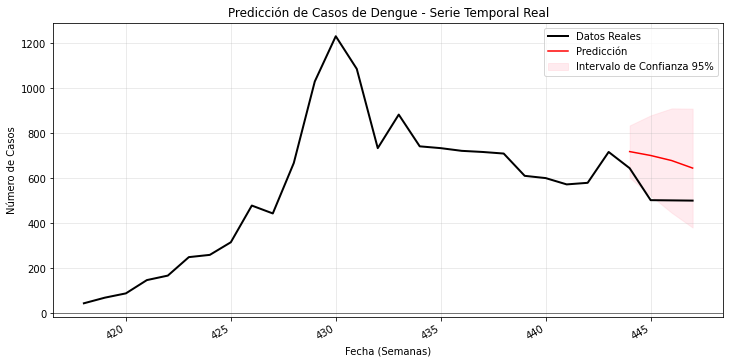

Error Absoluto Medio (MAE): 148.40 casos
Raíz del Error Cuadrático Medio (RMSE): 155.72 casos
Error Porcentual Absoluto Medio (MAPE): 28.74%


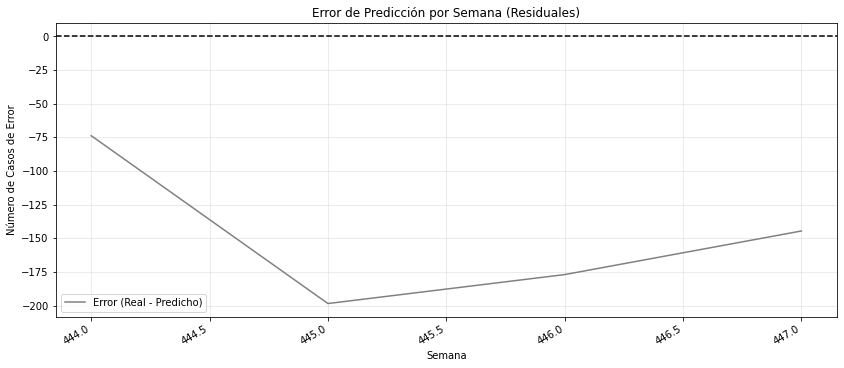

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
n_forecast = 4
y = df["Casos_Dengue"]
exog_vars =df[[ 'Temperatura med', 'Humedad Relat', 'Precipitaciones','Precipitaciones_lag5', 'Precipitaciones_lag9']]

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]
model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(0, 1, 4), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

In [1]:
print(111)

111


# Las Tunas

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Precipitaciones_lag10'],
      dtype='object')


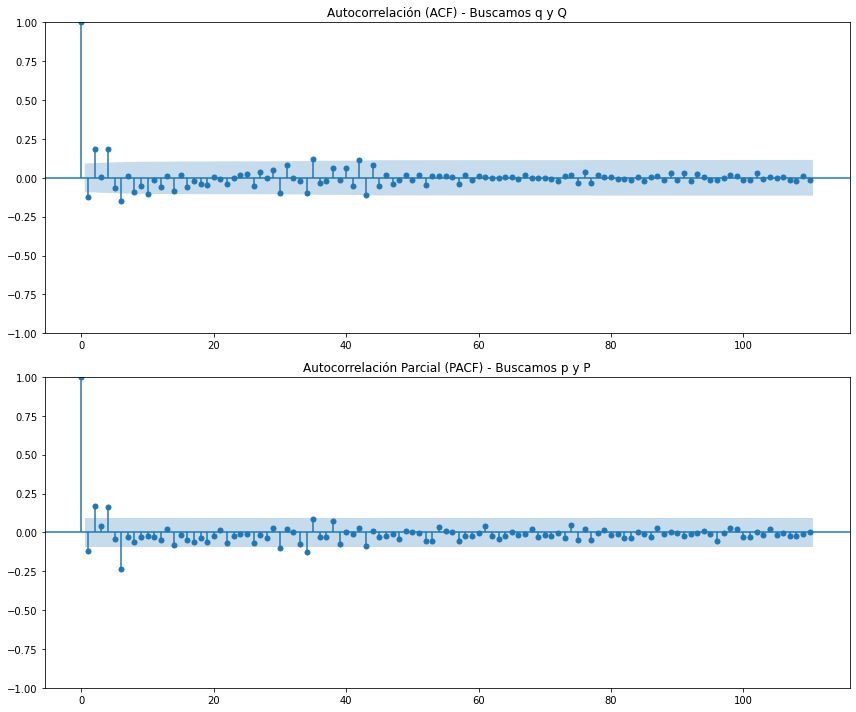

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Las_Tunas'

carpeta_salida = 'dataframes_con_lags'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [ ]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[['Temperatura med', 'Humedad Relat', 'Precipitaciones','Precipitaciones_lag10']]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 4551.5565489304645
(0, 1, 0) (0, 0, 1, 52) 4063.491319912418
(0, 1, 0) (0, 1, 0, 52) 4166.376936538772
(0, 1, 0) (0, 1, 1, 52) 3584.8308733975337
(0, 1, 0) (1, 0, 0, 52) 4070.865205613993
(0, 1, 0) (1, 0, 1, 52) 4063.477294493785
(0, 1, 0) (1, 1, 0, 52) 3605.08850494911


In [4]:
import itertools
import statsmodels.api as sm
import re
import ast

output_anterior = """
(0, 1, 0) (0, 0, 0, 52) 4551.5565489304645
(0, 1, 0) (0, 0, 1, 52) 4063.491319912418
(0, 1, 0) (0, 1, 0, 52) 4166.376936538772
(0, 1, 0) (0, 1, 1, 52) 3584.8308733975337
(0, 1, 0) (1, 0, 0, 52) 4070.865205613993
(0, 1, 0) (1, 0, 1, 52) 4063.477294493785
(0, 1, 0) (1, 1, 0, 52) 3605.08850494911
"""

pattern = re.compile(r'\((.*?)\)\s\((.*?)\)\s([\d.]+)')

resultados_anteriores = {}
for line in output_anterior.strip().split('\n'):
    match = pattern.search(line)
    if match:

        order_str = match.group(1)
        seasonal_order_str = match.group(2)
        aic_str = match.group(3)
        
        order = ast.literal_eval(f"({order_str})")
        seasonal_order = ast.literal_eval(f"({seasonal_order_str})") 
        
        aic = float(aic_str)
        
        # Guardar en el diccionario
        resultados_anteriores[(order, seasonal_order)] = aic

print(f"Se cargaron {len(resultados_anteriores)} resultados anteriores.")

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]

y = df["Casos_Dengue"]
exog_vars =df[['Temperatura med', 'Humedad Relat', 'Precipitaciones','Precipitaciones_lag10']]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

if resultados_anteriores:
    mejores_params_anteriores = min(resultados_anteriores, key=resultados_anteriores.get)
    mejor_aic = resultados_anteriores[mejores_params_anteriores]
    mejores_params = mejores_params_anteriores
    print(f"Reanudando búsqueda. Mejor resultado anterior: {mejores_params} con AIC: {mejor_aic}")
else:
    mejores_params = None
    mejor_aic = float("inf")
    print("Iniciando nueva búsqueda.")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        
        if (param, param_seasonal) in resultados_anteriores:
            continue
            
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(f"  {param} {param_seasonal} - AIC: {results.aic}")

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                print(f"*** ¡NUEVO MEJOR! {mejores_params} con AIC: {mejor_aic} ***")
                
        except Exception as e:
            continue

print("\n--- BÚSQUEDA FINALIZADA ---")
print(f"Mejor SARIMA encontrado: {mejores_params} con AIC: {mejor_aic}")

Se cargaron 7 resultados anteriores.
Reanudando búsqueda. Mejor resultado anterior: ((0, 1, 0), (0, 1, 1, 52)) con AIC: 3584.8308733975337
  (0, 1, 0) (1, 1, 1, 52) - AIC: 3583.099260563524
*** ¡NUEVO MEJOR! ((0, 1, 0), (1, 1, 1, 52)) con AIC: 3583.099260563524 ***
  (0, 1, 1) (0, 0, 0, 52) - AIC: 4539.957132585263
  (0, 1, 1) (0, 0, 1, 52) - AIC: 4052.34211513897
  (0, 1, 1) (0, 1, 0, 52) - AIC: 4157.0026415147495
  (0, 1, 1) (0, 1, 1, 52) - AIC: 3571.5812484850367
*** ¡NUEVO MEJOR! ((0, 1, 1), (0, 1, 1, 52)) con AIC: 3571.5812484850367 ***
  (0, 1, 1) (1, 0, 0, 52) - AIC: 4069.2927171167557
  (0, 1, 1) (1, 0, 1, 52) - AIC: 4052.5307840559103
  (0, 1, 1) (1, 1, 0, 52) - AIC: 3604.3542740453577
  (0, 1, 1) (1, 1, 1, 52) - AIC: 3571.0593914593837
*** ¡NUEVO MEJOR! ((0, 1, 1), (1, 1, 1, 52)) con AIC: 3571.0593914593837 ***
  (0, 1, 2) (0, 0, 0, 52) - AIC: 4521.236810169628
  (0, 1, 2) (0, 0, 1, 52) - AIC: 4034.6604367758373
  (0, 1, 2) (0, 1, 0, 52) - AIC: 4139.089238695357


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  (0, 1, 2) (0, 1, 1, 52) - AIC: 3557.860399595421
*** ¡NUEVO MEJOR! ((0, 1, 2), (0, 1, 1, 52)) con AIC: 3557.860399595421 ***


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  (0, 1, 2) (1, 0, 0, 52) - AIC: 4061.105239270795
  (0, 1, 2) (1, 0, 1, 52) - AIC: 4035.0018230469814


...

  (2, 1, 2) (1, 0, 1, 52) - AIC: 4034.1710917736546


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  (2, 1, 2) (1, 1, 0, 52) - AIC: 3572.2992714207126


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  (2, 1, 2) (1, 1, 1, 52) - AIC: 3555.84249769075

--- BÚSQUEDA FINALIZADA ---
Mejor SARIMA encontrado: ((2, 1, 2), (0, 1, 1, 52)) con AIC: 3554.396046163528


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


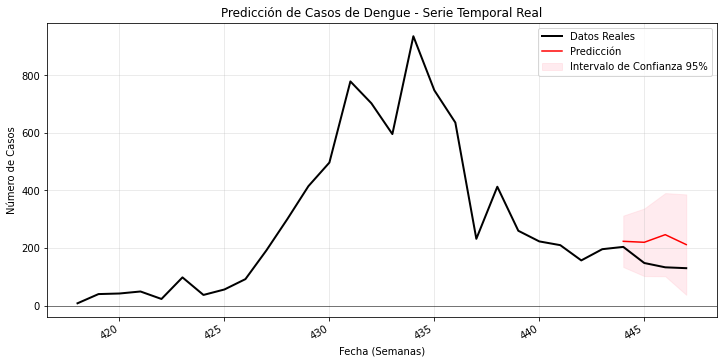

Error Absoluto Medio (MAE): 71.68 casos
Raíz del Error Cuadrático Medio (RMSE): 79.27 casos
Error Porcentual Absoluto Medio (MAPE): 51.61%


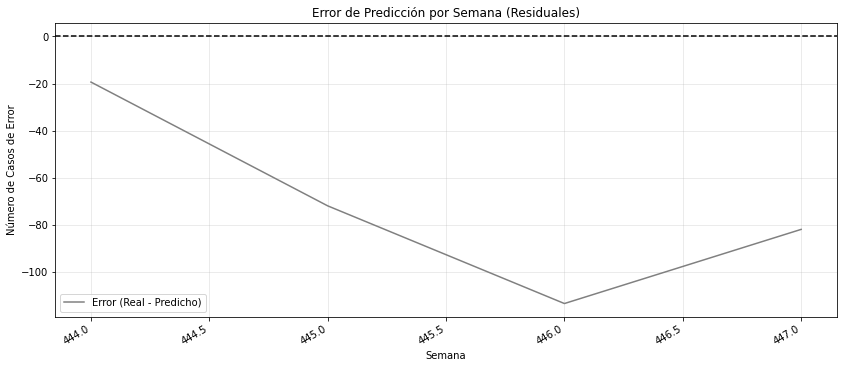

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(2, 1, 2), 
                      seasonal_order=(0, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Granma

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


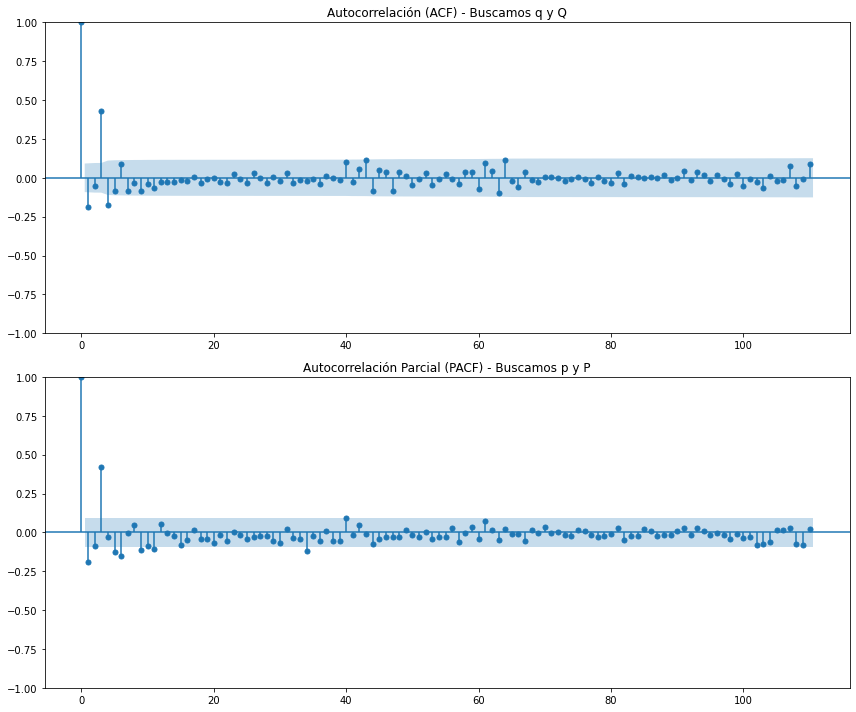

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Granma'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [7]:
import itertools
import statsmodels.api as sm

p =  [0,1,2,3]
q=[0,1,2,3,4]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[["Temp_Med","Hum_Rel","Precip"]]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 3916.1800025360853
(0, 1, 0) (0, 0, 1, 52) 3514.0449462488837
(0, 1, 0) (0, 1, 0, 52) 3738.5884463523803
(0, 1, 0) (0, 1, 1, 52) 3131.062618158872
(0, 1, 0) (1, 0, 0, 52) 3521.8398484792806
(0, 1, 0) (1, 0, 1, 52) 3515.999343574485
(0, 1, 0) (1, 1, 0, 52) 3215.411739170513
(0, 1, 0) (1, 1, 1, 52) 3133.032753845426
(0, 1, 1) (0, 0, 0, 52) 3894.2381976036577
(0, 1, 1) (0, 0, 1, 52) 3493.940678843587
(0, 1, 1) (0, 1, 0, 52) 3718.341229018937
(0, 1, 1) (0, 1, 1, 52) 3113.935977777359
(0, 1, 1) (1, 0, 0, 52) 3509.5255365758844
(0, 1, 1) (1, 0, 1, 52) 3495.9192238868072
(0, 1, 1) (1, 1, 0, 52) 3208.794490107606
(0, 1, 1) (1, 1, 1, 52) 3115.9066465691917
(0, 1, 2) (0, 0, 0, 52) 3867.8524304615667
(0, 1, 2) (0, 0, 1, 52) 3469.9845017874477
(0, 1, 2) (0, 1, 0, 52) 3689.190954798167
(0, 1, 2) (0, 1, 1, 52) 3094.8186745114326
(0, 1, 2) (1, 0, 0, 52) 3493.297107732342
(0, 1, 2) (1, 0, 1, 52) 3471.9683845844547
(0, 1, 2) (1, 1, 0, 52) 3199.9443840939043


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 2) (1, 1, 1, 52) 3096.8148210824584
(0, 1, 3) (0, 0, 0, 52) 3804.5501137342726
(0, 1, 3) (0, 0, 1, 52) 3413.225639570689
(0, 1, 3) (0, 1, 0, 52) 3623.3402375377054
(0, 1, 3) (0, 1, 1, 52) 3046.1608486160085
(0, 1, 3) (1, 0, 0, 52) 3443.760362501065
(0, 1, 3) (1, 0, 1, 52) 3415.2089253059066
(0, 1, 3) (1, 1, 0, 52) 3152.774779859983


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 3) (1, 1, 1, 52) 3048.768965646091
(0, 1, 4) (0, 0, 0, 52) 3775.663056878454
(0, 1, 4) (0, 0, 1, 52) 3387.0700854924853
(0, 1, 4) (0, 1, 0, 52) 3597.0980682826885
(0, 1, 4) (0, 1, 1, 52) 3025.15245405814
(0, 1, 4) (1, 0, 0, 52) 3424.971950372103


...

(3, 1, 4) (1, 0, 1, 52) 3372.663192994015


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(3, 1, 4) (1, 1, 0, 52) 3100.536317656423


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(3, 1, 4) (1, 1, 1, 52) 3013.194137889804
Mejor SARIMA: ((3, 1, 4), (0, 1, 1, 52)) con AIC: 3008.5727868019712


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


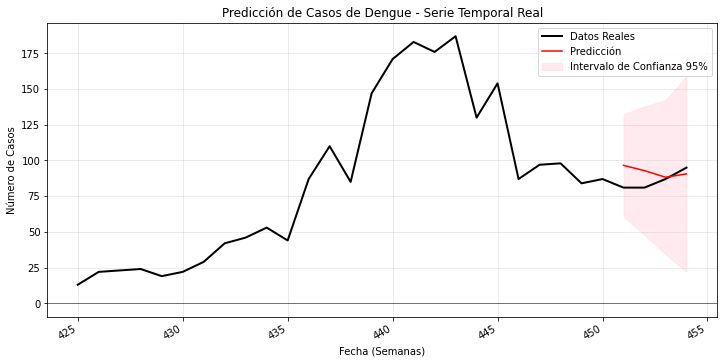

Error Absoluto Medio (MAE): 8.29 casos
Raíz del Error Cuadrático Medio (RMSE): 10.07 casos
Error Porcentual Absoluto Medio (MAPE): 10.00%


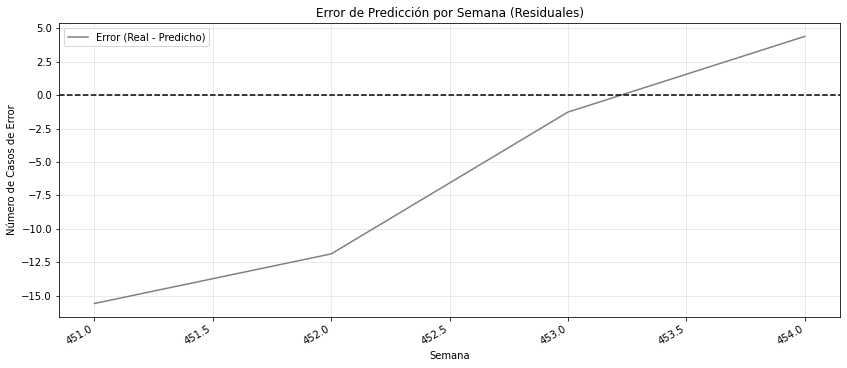

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(3, 1, 4), 
                      seasonal_order=(0, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Holguin 

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Precipitaciones_lag13'],
      dtype='object')


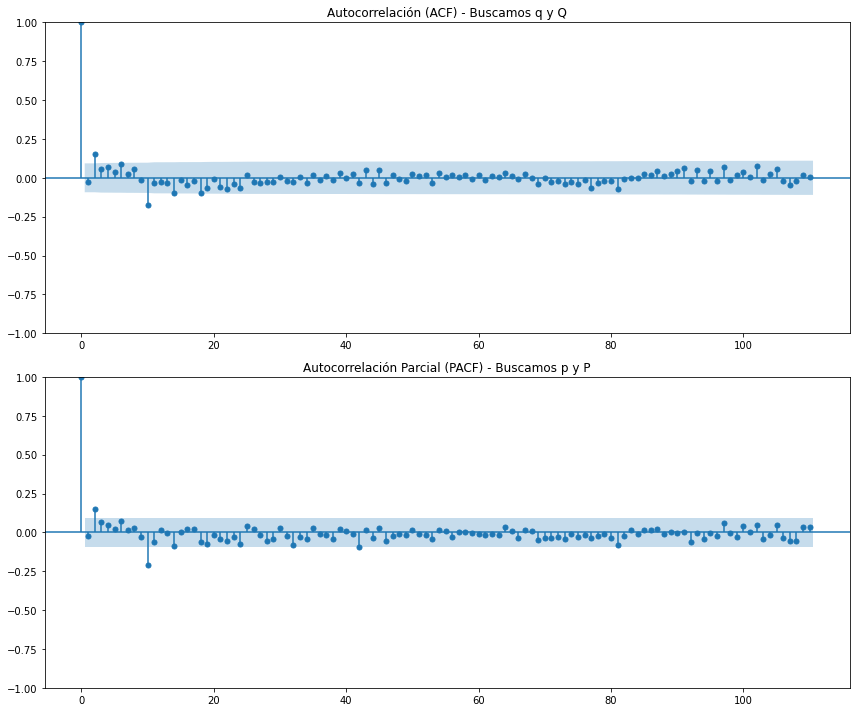

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Holguín'

carpeta_salida = 'dataframes_con_lags'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [10]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[['Temperatura med', 'Humedad Relat', 'Precipitaciones','Precipitaciones_lag13']]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 4979.693792035679
(0, 1, 0) (0, 0, 1, 52) 4402.559817353902
(0, 1, 0) (0, 1, 0, 52) 4613.452670897448
(0, 1, 0) (0, 1, 1, 52) 3867.8850398003233
(0, 1, 0) (1, 0, 0, 52) 4412.852083410481
(0, 1, 0) (1, 0, 1, 52) 4404.5014514313625
(0, 1, 0) (1, 1, 0, 52) 3926.8282316622754
(0, 1, 0) (1, 1, 1, 52) 3869.464564513552
(0, 1, 1) (0, 0, 0, 52) 4971.193177725561
(0, 1, 1) (0, 0, 1, 52) 4394.017355645543
(0, 1, 1) (0, 1, 0, 52) 4604.542695815289
(0, 1, 1) (0, 1, 1, 52) 3859.370883244723
(0, 1, 1) (1, 0, 0, 52) 4414.651730584453
(0, 1, 1) (1, 0, 1, 52) 4395.95574163858
(0, 1, 1) (1, 1, 0, 52) 3928.268708657707
(0, 1, 1) (1, 1, 1, 52) 3860.929152271671
(0, 1, 2) (0, 0, 0, 52) 4954.038568572609
(0, 1, 2) (0, 0, 1, 52) 4374.313089957246
(0, 1, 2) (0, 1, 0, 52) 4592.703175411973


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 2) (0, 1, 1, 52) 3844.3214730980644
(0, 1, 2) (1, 0, 0, 52) 4407.227715334271
(0, 1, 2) (1, 0, 1, 52) 4376.3124672230515
(0, 1, 2) (1, 1, 0, 52) 3925.695860201253


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 2) (1, 1, 1, 52) 3846.0105156860027
(1, 1, 0) (0, 0, 0, 52) 4981.46251287841
(1, 1, 0) (0, 0, 1, 52) 4404.299226628475
(1, 1, 0) (0, 1, 0, 52) 4615.440978983868
(1, 1, 0) (0, 1, 1, 52) 3869.881064819061
(1, 1, 0) (1, 0, 0, 52) 4404.243953057046
(1, 1, 0) (1, 0, 1, 52) 4406.236924248819
(1, 1, 0) (1, 1, 0, 52) 3917.4135658145565
(1, 1, 0) (1, 1, 1, 52) 3871.4556823020926
(1, 1, 1) (0, 0, 0, 52) 4969.7144821291295
(1, 1, 1) (0, 0, 1, 52) 4389.415825920879
(1, 1, 1) (0, 1, 0, 52) 4604.512570119996


...

(2, 1, 2) (1, 0, 1, 52) 4376.869532906346


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 0, 52) 3900.1371382724756


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 1, 52) 3846.255430850106
Mejor SARIMA: ((1, 1, 2), (0, 1, 1, 52)) con AIC: 3843.814292061048


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


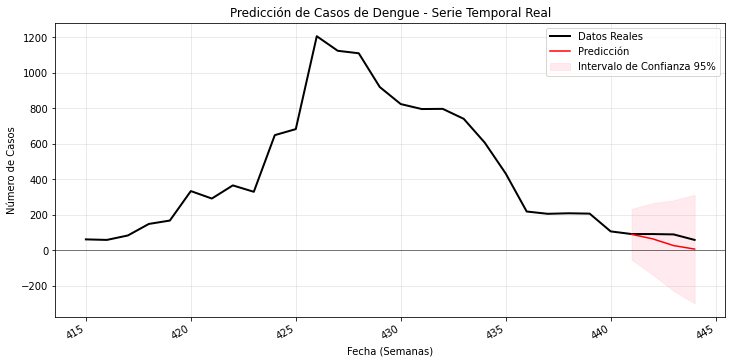

Error Absoluto Medio (MAE): 35.77 casos
Raíz del Error Cuadrático Medio (RMSE): 42.87 casos
Error Porcentual Absoluto Medio (MAPE): 47.11%


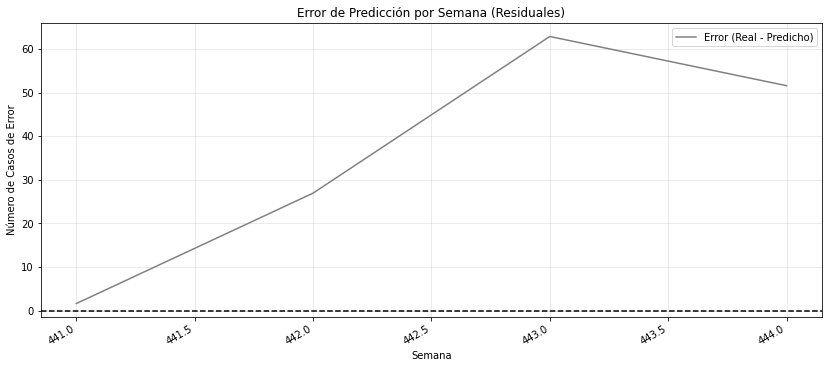

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(1, 1, 2), 
                      seasonal_order=(0, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Santiago de Cuba 

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Precipitaciones_lag0', 'Precipitaciones_lag1', 'Precipitaciones_lag4',
       'Temperatura med_lag6', 'Temperatura med_lag12',
       'Temperatura med_lag13', 'Temperatura med_lag14',
       'Temperatura med_lag15'],
      dtype='object')


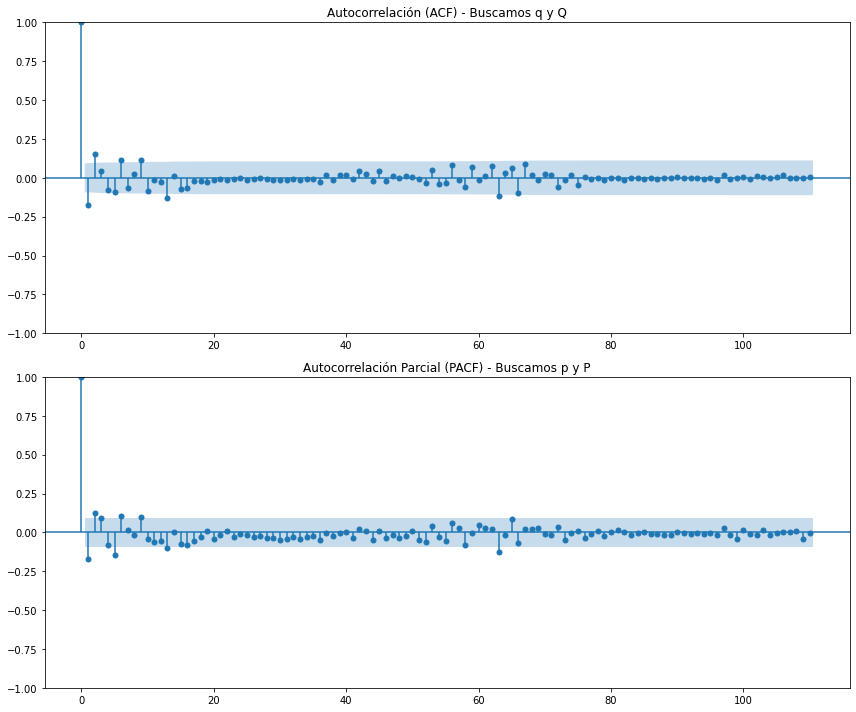

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Santiago_de_Cuba'

carpeta_salida = 'dataframes_con_lags'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [14]:
import itertools
import statsmodels.api as sm

p =  [0,1,2,3]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[["Temperatura med", 'Humedad Relat', 'Precipitaciones', 'Precipitaciones_lag0', 'Precipitaciones_lag1', 'Precipitaciones_lag4','Temperatura med_lag6', 'Temperatura med_lag12','Temperatura med_lag13', 'Temperatura med_lag14','Temperatura med_lag15']]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 5520.7756464881


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 0) (0, 0, 1, 52) 4843.19775205442
(0, 1, 0) (0, 1, 0, 52) 5098.783116516916


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 0) (0, 1, 1, 52) 4172.012900363676


...

(3, 1, 2) (1, 0, 1, 52) 4790.17207962817


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(3, 1, 2) (1, 1, 0, 52) 4209.508863997172


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(3, 1, 2) (1, 1, 1, 52) 4201.742070508868
Mejor SARIMA: ((0, 1, 2), (0, 1, 1, 52)) con AIC: 4149.412165830398


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


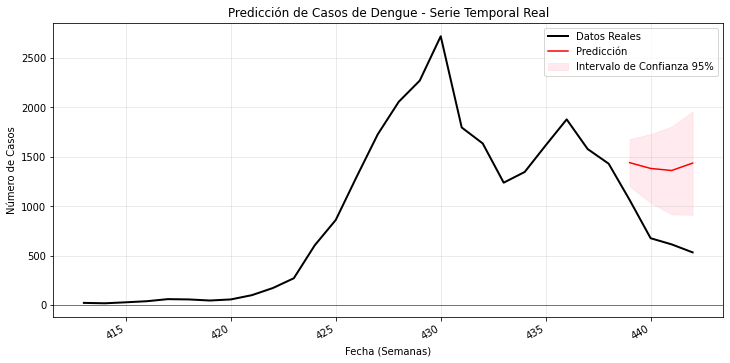

Error Absoluto Medio (MAE): 683.23 casos
Raíz del Error Cuadrático Medio (RMSE): 709.51 casos
Error Porcentual Absoluto Medio (MAPE): 107.56%


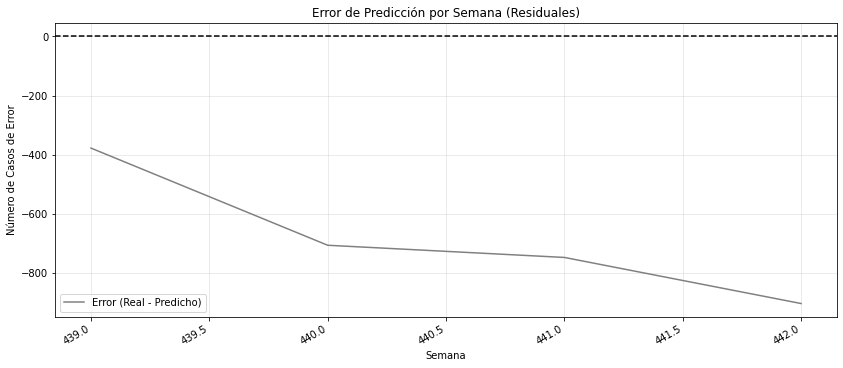

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(0, 1, 2), 
                      seasonal_order=(0, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Guantanamo 

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


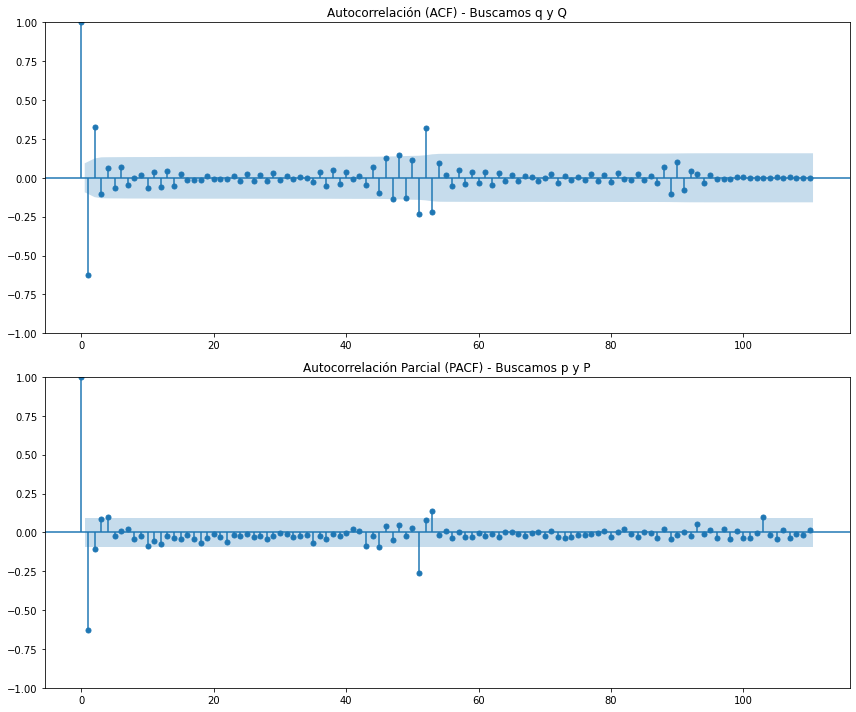

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Guantánamo'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [17]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[["Temp_Med","Hum_Rel","Precip"]]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 5393.010985705368
(0, 1, 0) (0, 0, 1, 52) 4667.920301854889
(0, 1, 0) (0, 1, 0, 52) 4791.948551816164
(0, 1, 0) (0, 1, 1, 52) 4050.3793282071156
(0, 1, 0) (1, 0, 0, 52) 4612.358685913723
(0, 1, 0) (1, 0, 1, 52) 4446.5571465965
(0, 1, 0) (1, 1, 0, 52) 4064.243812366376
(0, 1, 0) (1, 1, 1, 52) 3979.4585494827998
(0, 1, 1) (0, 0, 0, 52) 5212.343717224439


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 1) (0, 0, 1, 52) 4528.370014812163
(0, 1, 1) (0, 1, 0, 52) 4652.79842087046
(0, 1, 1) (0, 1, 1, 52) 3939.161407240489


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 1) (1, 0, 0, 52) 4500.117669466399


...

(2, 1, 2) (0, 1, 1, 52) 3879.2257718497126


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 0, 0, 52) 4384.8462768023965


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 0, 1, 52) 4269.665381308485
(2, 1, 2) (1, 1, 0, 52) 3892.2176317866906
(2, 1, 2) (1, 1, 1, 52) 3849.391537947148
Mejor SARIMA: ((0, 1, 2), (1, 1, 1, 52)) con AIC: 3847.554303484828


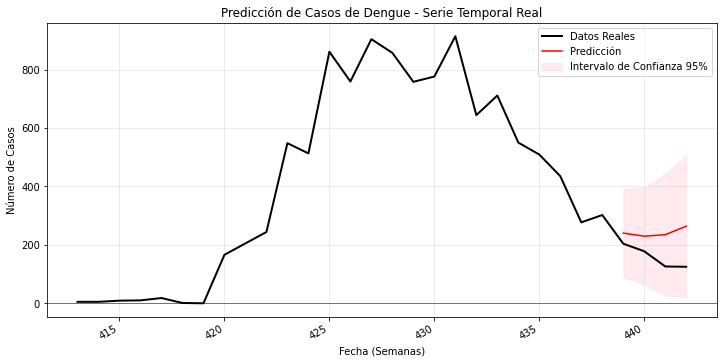

Error Absoluto Medio (MAE): 83.91 casos
Raíz del Error Cuadrático Medio (RMSE): 93.72 casos
Error Porcentual Absoluto Medio (MAPE): 61.07%


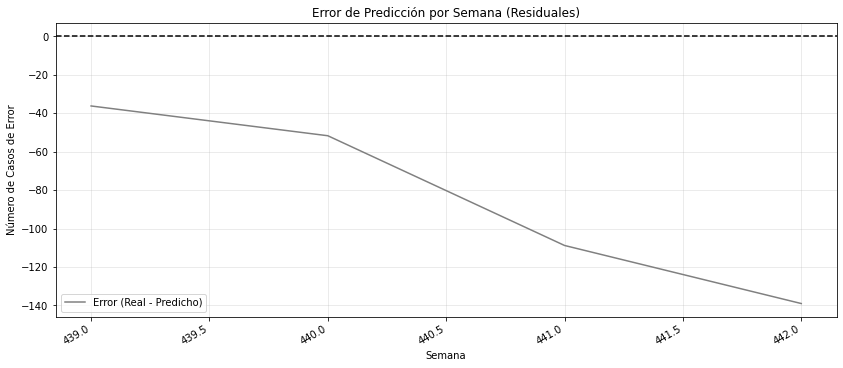

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(0, 1, 2), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# Isla de la Juventud 

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')


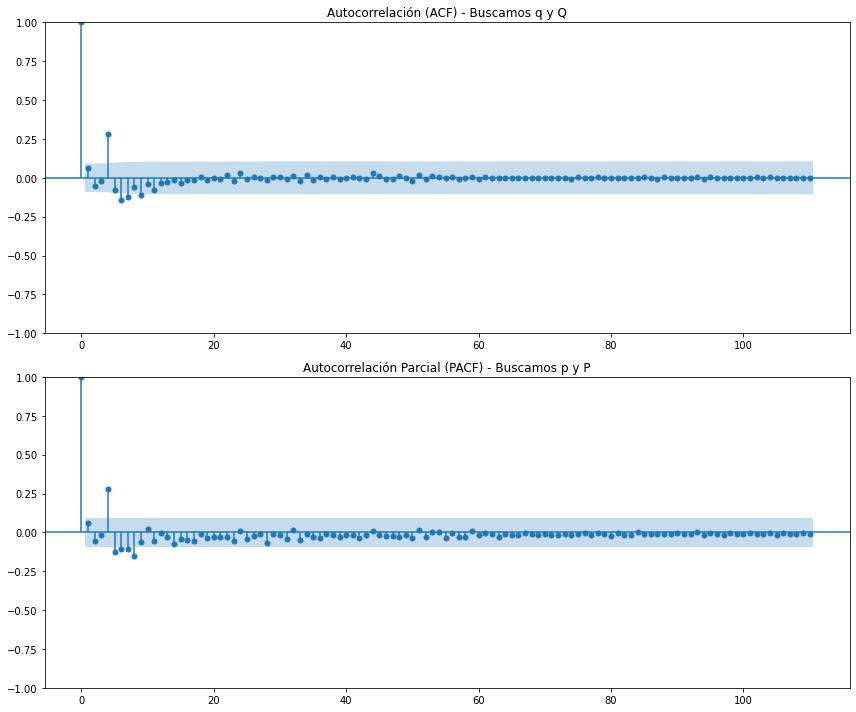

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pandas as pd
import os

nombre_provincia = 'Isla_de_la_Juventud'

carpeta_salida = 'dataframes_provincias'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

serie_diferenciada = df["Casos_Dengue"].diff().dropna()

# ACF: Ayuda a identificar q (MA) y Q (SMA)
plot_acf(serie_diferenciada, lags=110, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Buscamos q y Q')

# PACF: Ayuda a identificar p (AR) y P (SAR)
plot_pacf(serie_diferenciada, lags=110, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Buscamos p y P')

plt.tight_layout()
plt.show()

In [21]:
import itertools
import statsmodels.api as sm

p =  [0,1,2]
q=[0,1,2]
d = [1]
P = D = Q = range(0, 2) # Estacionales 0 o 1
s = 52 

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]
y = df["Casos_Dengue"]
exog_vars =df[["Temp_Med","Hum_Rel","Precip"]]

n_forecast = 4

train_y = y[:-n_forecast]
train_exog = exog_vars[:-n_forecast]
test_y = y[-n_forecast:]
test_exog = exog_vars[-n_forecast:]

mejores_params = None
mejor_aic = float("inf")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train_y,
                                            exog=train_exog,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit(disp=False)
            print(param,param_seasonal,results.aic)

            if results.aic < mejor_aic:
                mejor_aic = results.aic
                mejores_params = (param, param_seasonal)
                
        except:
            continue

print(f"Mejor SARIMA: {mejores_params} con AIC: {mejor_aic}")

(0, 1, 0) (0, 0, 0, 52) 3565.6185855606645
(0, 1, 0) (0, 0, 1, 52) 3128.479688509835
(0, 1, 0) (0, 1, 0, 52) 3221.6030542382036
(0, 1, 0) (0, 1, 1, 52) 2772.719632190443
(0, 1, 0) (1, 0, 0, 52) 3135.1660006769007
(0, 1, 0) (1, 0, 1, 52) 3130.202965473921
(0, 1, 0) (1, 1, 0, 52) 2779.6971261948265
(0, 1, 0) (1, 1, 1, 52) 2774.7062502759286
(0, 1, 1) (0, 0, 0, 52) 3558.819491504878
(0, 1, 1) (0, 0, 1, 52) 3091.6643897631166
(0, 1, 1) (0, 1, 0, 52) 3216.245844751432
(0, 1, 1) (0, 1, 1, 52) 2744.0824647428176
(0, 1, 1) (1, 0, 0, 52) 3104.6566493559358
(0, 1, 1) (1, 0, 1, 52) 3092.706963300803
(0, 1, 1) (1, 1, 0, 52) 2758.3559784899485
(0, 1, 1) (1, 1, 1, 52) 2745.10316860753
(0, 1, 2) (0, 0, 0, 52) 3553.2701973850753
(0, 1, 2) (0, 0, 1, 52) 3085.551276098883
(0, 1, 2) (0, 1, 0, 52) 3210.867491759577
(0, 1, 2) (0, 1, 1, 52) 2737.6340406944832
(0, 1, 2) (1, 0, 0, 52) 3105.357688273336
(0, 1, 2) (1, 0, 1, 52) 3086.6693751895546
(0, 1, 2) (1, 1, 0, 52) 2758.825282749551


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(0, 1, 2) (1, 1, 1, 52) 2738.6288494021683
(1, 1, 0) (0, 0, 0, 52) 3565.9435840639444
(1, 1, 0) (0, 0, 1, 52) 3109.5934840603672
(1, 1, 0) (0, 1, 0, 52) 3223.4244820837084
(1, 1, 0) (0, 1, 1, 52) 2758.766572697555
(1, 1, 0) (1, 0, 0, 52) 3108.8776169881257
(1, 1, 0) (1, 0, 1, 52) 3110.8773177910807
(1, 1, 0) (1, 1, 0, 52) 2758.6804368815056
(1, 1, 0) (1, 1, 1, 52) 2760.0882870459054
(1, 1, 1) (0, 0, 0, 52) 3560.611771326453
(1, 1, 1) (0, 0, 1, 52) 3093.0932234182974
(1, 1, 1) (0, 1, 0, 52) 3218.191894562544
(1, 1, 1) (0, 1, 1, 52) 2745.4000696640624
(1, 1, 1) (1, 0, 0, 52) 3099.1508754674765
(1, 1, 1) (1, 0, 1, 52) 3094.1726594085503
(1, 1, 1) (1, 1, 0, 52) 2752.497227062573
(1, 1, 1) (1, 1, 1, 52) 2746.4189766868394
(1, 1, 2) (0, 0, 0, 52) 3548.1002541289163
(1, 1, 2) (0, 0, 1, 52) 3032.8894039357147
(1, 1, 2) (0, 1, 0, 52) 3208.5393996289686


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(1, 1, 2) (0, 1, 1, 52) 2738.7926149289824


...

(2, 1, 2) (1, 0, 1, 52) 3004.071251563548


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 0, 52) 2685.577046202303


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 1, 52) 2676.5490103619304
Mejor SARIMA: ((2, 1, 2), (1, 1, 1, 52)) con AIC: 2676.5490103619304


/home/jennifer/Documentos/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


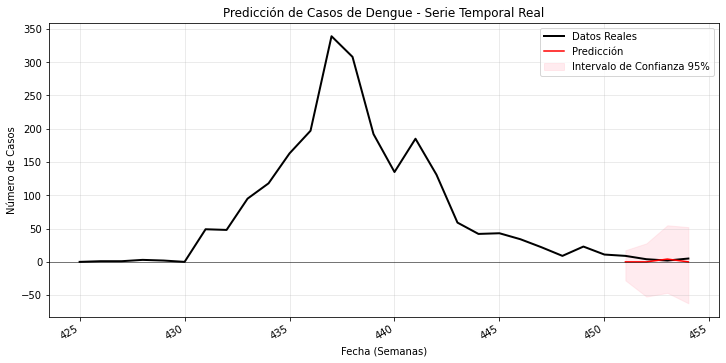

Error Absoluto Medio (MAE): 5.05 casos
Raíz del Error Cuadrático Medio (RMSE): 5.63 casos
Error Porcentual Absoluto Medio (MAPE): 102.31%


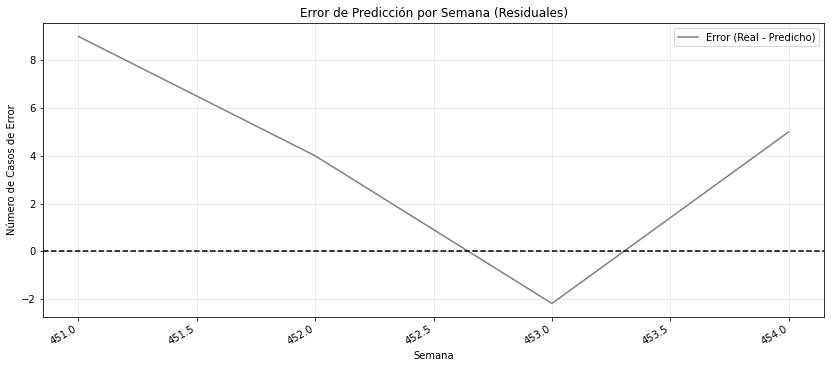

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_final = SARIMAX(train_y, 
                      exog=train_exog, 
                      order=(2, 1, 2), 
                      seasonal_order=(1, 1, 1, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
results_final = model_final.fit(disp=False)

forecast = results_final.get_forecast(steps=n_forecast, exog=test_exog)
forecast_df = forecast.summary_frame()
forecast_df.index = test_y.index

forecast_df['mean'] = np.clip(forecast_df['mean'], 0, None)
# forecast_df['mean_ci_lower'] = np.clip(forecast_df['mean_ci_lower'], 0, None)
# forecast_df['mean_ci_upper'] = np.clip(forecast_df['mean_ci_upper'], 0, None)

plt.figure(figsize=(12, 6))

plt.plot(y.index[-30:], y[-30:], label='Datos Reales', color='black', linewidth=2)

plt.plot(test_y.index, forecast_df['mean'], label='Predicción', color='red')

plt.fill_between(forecast_df.index, 
                 forecast_df['mean_ci_lower'], 
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Intervalo de Confianza 95%')

plt.gcf().autofmt_xdate() 

plt.title('Predicción de Casos de Dengue - Serie Temporal Real')
plt.xlabel('Fecha (Semanas)')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Línea en el cero
plt.show()
y_true = test_y
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} casos")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} casos")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape*100:.2f}%")

error_semanal = y_true - y_pred

plt.figure(figsize=(14, 6))
plt.plot(error_semanal.index, error_semanal, color='gray', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Error de Predicción por Semana (Residuales)')
plt.xlabel('Semana')
plt.ylabel('Número de Casos de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()